# Result evaluation notebook

Here we analyze and evaluate the performance csv produced by the eval_* notebook.

## Table of contents

- [1. Setup](#1-setup)
- [2. Load datasets](#2-load-datasets)
  - [2.1 Join the datasets for the evaluation](#21-join-the-datasets-for-the-evaluation)
- [3. Evaluation metrics](#3-evaluation-metrics)
  - [3.1 Equivalence helpers](#31-equivalence-helpers)
  - [3.2 Global metrics](#32-global-metrics)
    - [3.2.1 End-to-end quality](#321-end-to-end-quality)
    - [3.2.2 Ranking diagnostic](#322-ranking-diagnostic)
    - [3.2.3 Concept-text match (annotation-independent retriever diagnostic)](#323-concept-text-match-annotation-independent-retriever-diagnostic)
    - [3.2.4 Retrieve diagnostic](#324-retrieve-diagnostic)
    - [3.2.5 Resolve diagnostic](#325-resolve-diagnostic)
    - [3.2.6 Tool usage](#326-tool-usage)
    - [3.2.7 Latency](#327-latency)
  - [3.3 Local (Sentence-level) diagnostics](#33-local-sentence-level-diagnostics)
  - [3.4 Final metrics dataframes](#34-final-metrics-dataframes)
- [4. Plot results](#4-plot-results)
  - [4.1 Quality heatmaps](#41-quality-heatmaps)
    - [4.1.1 Global overview](#411-global-overview)
    - [4.1.2 Turn point of view](#412-turn-point-of-view)
  - [4.2 Retrieve & ranking](#42-retrieve-ranking)
    - [4.2.1 How much the ranker is losing along the way?](#421-how-much-the-ranker-is-losing-along-the-way)
    - [4.2.2 Where the gold pictogram lands in the pool, and how often it's buried below the window cut](#422-where-the-gold-pictogram-actually-lands-inside-the-ranked-pool-and-what-fraction-of-the-time-it-gets-buried-below-the-window-cut)
    - [4.2.3 pool vs window comparison, using the annotation-independent concept-text match](#423-pool-vs-window-comparison-but-using-the-annotation-independent-concept-text-match-instead-of-gold)
    - [4.2.4 pool lift over random baseline](#424-pool-lift-over-random-baseline)
    - [4.2.5 gold vs. candidates gap](#425-gold-vs-candidates-gap)
  - [4.3 Resolve & tool usage](#43-resolve-tool-usage)
  - [4.4 Latency](#44-latency)
  - [4.5 Sentence difficulty](#45-sentence-difficulty)
- [5. Evaluation dataset audit](#5-evaluation-dataset-audit)
  - [5.1 Inspect the gold_id, window and pool visually — DEBUG SECTION](#51-inspect-visually-the-gold_id-the-window-and-the-pool-debug-section)
  - [5.2 Inspect the gold metadata for intended-meaning mismatches — DEBUG SECTION](#52-inspect-the-metadata-of-the-gold-to-see-whether-the-gold_id-actually-matches-the-intended-meaning-debug-section)
  - [5.3 Annotation type diagnostic](#53-annotation-type-diagnostic)
  - [5.4 Soft zero scores breakdown](#54-soft-zero-scores-breakdown)
  - [5.5 Full dataset check](#55-full-dataset-check)

## 1. Setup

In [1]:
import os, json, ast, sys, math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image
from dotenv import load_dotenv
from IPython.display import display, HTML

import warnings
warnings.filterwarnings(action="ignore")

import logging
logging.getLogger("agent.resolve").setLevel(logging.WARNING)

PROJECT_ROOT = Path(".").resolve().parent.parent.parent.parent

EVAL_ANN_FINAL = PROJECT_ROOT / "annotation" / "eval_final.parquet"
EVAL_COLAB = PROJECT_ROOT / "eval" / "cpu-colab" / "explore" / "sequential_blocks" / "eval_cpu_colab.csv"

_DATASET_DIR = PROJECT_ROOT / "app" / "datasets" / "en_eval"

load_dotenv(PROJECT_ROOT / "app" / ".env")  # maybe they will be useful to retrieve

# Used by section 3.4 and 5.5 to resolve concept text the same way the agent does
sys.path.insert(0, str(PROJECT_ROOT / "app" / "src"))

print(f"PROJECT_ROOT   : {PROJECT_ROOT}  (exists={PROJECT_ROOT.exists()})")
print(f"EVAL_ANN_FINAL : {EVAL_ANN_FINAL}  (exists={EVAL_ANN_FINAL.exists()})")
print(f"EVAL_COLAB     : {EVAL_COLAB}  (exists={EVAL_COLAB.exists()})")


PROJECT_ROOT   : /Users/pelle/Development/GitHub/aac-mcp-agent  (exists=True)
EVAL_ANN_FINAL : /Users/pelle/Development/GitHub/aac-mcp-agent/annotation/eval_final.parquet  (exists=True)
EVAL_COLAB     : /Users/pelle/Development/GitHub/aac-mcp-agent/eval/cpu-colab/explore/sequential_blocks/eval_cpu_colab.csv  (exists=True)


## 2. Load datasets

In [2]:
df_ann  = pd.read_parquet(EVAL_ANN_FINAL)
df_exec = pd.read_csv(EVAL_COLAB)
df_exec.info()

<class 'pandas.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   row_idx              606 non-null    int64  
 1   input_type           606 non-null    str    
 2   turn_pos             606 non-null    int64  
 3   concept_text         606 non-null    str    
 4   called_get_time      606 non-null    bool   
 5   called_get_schedule  606 non-null    bool   
 6   needs_context        606 non-null    bool   
 7   predicted_ids        606 non-null    str    
 8   pool_ids             606 non-null    str    
 9   plan_method          606 non-null    str    
 10  resolve_method       606 non-null    str    
 11  planner_concepts     606 non-null    str    
 12  turn_time_s          606 non-null    float64
 13  model_name           606 non-null    str    
 14  window_size          606 non-null    int64  
dtypes: bool(3), float64(1), int64(3), str(8)
memory usa

We can see that ome columns are stored as strings (because they came from a CSV), so we need to parse them back into Python lists before we can use them.

In [3]:
df_exec["predicted_ids"]    = df_exec["predicted_ids"].apply(ast.literal_eval)
df_exec["resolve_methods"]  = df_exec["resolve_method"].apply(ast.literal_eval)
del df_exec["resolve_method"] 
df_exec["planner_concepts"] = df_exec["planner_concepts"].apply(ast.literal_eval)
df_exec["pool_ids"]         = df_exec["pool_ids"].apply(ast.literal_eval)

### 2.1 Join the datasets for the evaluation

In [4]:
# Use a 1 row per turn format to simplify the evaluation of each turn
df_gold = (
    df_ann
    .rename_axis("row_idx")   # preserve original parquet index as row_idx
    .reset_index()
    .explode("concepts")
    .reset_index(drop=True)
)

# Unpack the dictionary structure of "concepts"
df_gold["concept_text"]  = df_gold["concepts"].apply(lambda c: c["concept_text"])
df_gold["gold_id"]       = df_gold["concepts"].apply(lambda c: int(c["gold_id"]))
df_gold["candidate_ids"] = df_gold["concepts"].apply(lambda c: list(c["candidate_ids"]))
df_gold.drop(columns=["concepts"], inplace=True)

# Assign turn_pos as the position of each concept within its sentence
df_gold["turn_pos"] = df_gold.groupby("row_idx").cumcount()

# Join the two datasets on row_idx and turn_pos, which uniquely identify an execution turn
df = df_exec.merge(
    df_gold[["row_idx", "turn_pos", "concept_text", "gold_id", "candidate_ids", "time_of_day", "event_time", "schedule"]],
    on=["row_idx", "turn_pos"],
    how="left",
)
del df["concept_text_x"]
df["concept_text"] = df["concept_text_y"]
del df["concept_text_y"]

# Remove useless attributes and reoder useful ones
df = df[[
    # Identifiers
    "model_name", "window_size", "row_idx", "input_type", "turn_pos", 
    # For metrics
    "gold_id", "candidate_ids", "predicted_ids", "pool_ids", "planner_concepts", "resolve_methods", 
    "needs_context",  "turn_time_s",
    # For debug
    "concept_text"
]]

print(df.info())
display(df["turn_time_s"].describe())
df.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model_name        606 non-null    str    
 1   window_size       606 non-null    int64  
 2   row_idx           606 non-null    int64  
 3   input_type        606 non-null    str    
 4   turn_pos          606 non-null    int64  
 5   gold_id           606 non-null    int64  
 6   candidate_ids     606 non-null    object 
 7   predicted_ids     606 non-null    object 
 8   pool_ids          606 non-null    object 
 9   planner_concepts  606 non-null    object 
 10  resolve_methods   606 non-null    object 
 11  needs_context     606 non-null    bool   
 12  turn_time_s       606 non-null    float64
 13  concept_text      606 non-null    str    
dtypes: bool(1), float64(1), int64(4), object(5), str(3)
memory usage: 75.8+ KB
None


count    606.000000
mean      57.931955
std       59.828083
min       11.989000
25%       16.952000
50%       20.870500
75%      117.203500
max      256.826000
Name: turn_time_s, dtype: float64

,model_name,window_size,row_idx,input_type,turn_pos,gold_id,candidate_ids,predicted_ids,pool_ids,planner_concepts,resolve_methods,needs_context,turn_time_s,concept_text
0,qwen2.5:3b,10,1125,clear,0,37810,"[9851, 37810, 25133, 8643, 5946, 4889, 6955, 6...","[6632, 2617, 3030, 3117, 31807, 7309, 7310, 32...","[6632, 2617, 3030, 3117, 31807, 7309, 7310, 32...","[I, math, problem, struggle, afternoon, time, ...","[exact, embedding, exact, none, exact, exact, ...",False,157.978,I
1,qwen2.5:3b,10,1125,clear,1,36717,"[9851, 37810, 8643, 36717, 36600, 37639, 30991...","[6480, 6481, 32554, 10260, 36373, 32304, 5556,...","[6480, 6481, 32554, 10260, 36373, 32304, 5556,...","[He, math, problem, student, classroom, teache...","[exact, embedding, exact, exact, exact, exact,...",False,16.771,struggle


## 3. Evaluation metrics

After grouping for `model_name` and `window_size` we compute the performances.

The metrics are organized in two levels:

- **Global metrics**: each turn is independent (teacher forcing), so we aggregate across all turns.
- **Sentence-level diagnostics**: aggregate by `(row_idx, input_type)` to surface systematically difficult sentences or suspicious gold annotations.

Moreover we differentiate 2 types of pictogram equivalence in the metrics (defined in the following cell):
- **hard**: just compare the numeric id, looking for the exact match.
- **soft**: combine the metadata of the two pictograms (synsets, categories, keywords, tags) into a weighted Jaccard score, and call it a match if the score passes a threshold. This gives us a less black-and-white notion of correctness, since two different pictograms can still be semantically close.



### 3.1 Equivalence helpers

In [5]:
##### Load metadata ###########################################################

with open(_DATASET_DIR / "pictograms.json") as f:
    _PICT_META: dict[str, dict] = json.load(f)  # keyed by str(id)

##### Parameyers #################################################################

_W_SYNSET   = 0.40
_W_CATEGORY = 0.25
_W_KEYWORD  = 0.25
_W_TAG      = 0.10
_SOFT_THRESHOLD = 0.3  

#### Helpers ##################################################################

def _meta(pid: int) -> dict | None:
    return _PICT_META.get(str(pid))

def _jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def _keywords_set(meta: dict) -> set[str]:
    return {kw["keyword"].lower() for kw in meta.get("keywords", [])}

def _soft_score(pid1: int, pid2: int) -> float:
    """
    Weighted Jaccard across synsets, categories, keywords, tags.
    Returns a float in [0, 1].
    """
    m1, m2 = _meta(pid1), _meta(pid2)
    if m1 is None or m2 is None:
        return 0.0

    synset_score    =  _jaccard(  set(m1.get("synsets",   []))  ,  set(m2.get("synsets",   []))  )
    category_score  =  _jaccard(  set(m1.get("categories",[]))  ,  set(m2.get("categories",[]))  )
    keyword_score   =  _jaccard(  _keywords_set(m1           )  ,  _keywords_set(m2           )  )
    tag_score       =  _jaccard(  set(m1.get("tags",      []))  ,  set(m2.get("tags",      []))  )

    return _W_SYNSET*synset_score + _W_CATEGORY*category_score + _W_KEYWORD*keyword_score + _W_TAG*tag_score

#############################################################################
#### Public API #############################################################
#############################################################################

# NOTE: useful to generalize the equivalence

def pict_equiv(pid1: int, pid2: int, method: str = "hard") -> bool:
    """
    Returns True if pid1 and pid2 are considered equivalent.

    method="hard" -> exact ID match.
    
    method="soft" —> weighted Jaccard over synsets, categories, keywords, tags
                    compared against _SOFT_THRESHOLD.
    """
    match method:
        case "hard":
            return pid1 == pid2
        case "soft":
            return _soft_score(pid1, pid2) >= _SOFT_THRESHOLD
        case _:
            raise ValueError(f"Unsupported method '{method}'. Use 'hard' or 'soft'.")

In [6]:
# Another helper is the set of all ARASAAC keywords, used by resolve_concept

_kw_index_path = _DATASET_DIR / "keyword_index.json" 
with open(_kw_index_path) as _f:
    _kw_index_raw = json.load(_f)

_KW_SET: set[str] = set(_kw_index_raw.keys())

print(f"_KW_SET loaded: {len(_KW_SET):,} keywords")

_KW_SET loaded: 15,722 keywords


### 3.2 Global metrics

#### 3.2.1 End-to-end quality

We measure how well the agent is following the ground truths:

- **Golden hit**: the gold pictogram ID is present in the predicted window. Boolean per turn, aggregated as mean over all the turns. 

- **Candiates hit**: fraction of annotated acceptable alternatives
that the retriever surfaces in the pool. Float per turn, aggregated as mean over all the turns.

In [7]:
#### Hit-rate helpers ###########################################################
def _gold_hit(df, target_col: str, method: str):
    return df.apply(
        lambda r: any(pict_equiv(r["gold_id"], pid, method) for pid in r[target_col]),
        axis=1,
    )

def _candidates_hit_row(candidates: list, targets: list, method: str) -> float:
    hits = sum(
        any(pict_equiv(cid, tid, method) for tid in targets)
        for cid in candidates
    )
    return hits / len(candidates)

def _candidates_hit(df, target_col: str, method: str):
    return df.apply(
        lambda r: _candidates_hit_row(r["candidate_ids"], r[target_col], method),
        axis=1,
    )

#### GOLDEN HIT ################################################################################
gold_window_hard = _gold_hit(df, "predicted_ids", "hard")
gold_window_soft = _gold_hit(df, "predicted_ids", "soft")

#### CANDIDATES HIT ################################################################################
candidates_window_hard = _candidates_hit(df, "predicted_ids", "hard")
candidates_window_soft = _candidates_hit(df, "predicted_ids", "soft")

#### 3.2.2 Ranking diagnostic

Since the expansion is likely to overcome the window size, we have to check that the correct pictograms were not discarded when ranking from the expanded pool. In this way, if those metrics are higher than the previous ones we know that the ranking is problematic.

In [8]:
gold_pool_hard = _gold_hit(df, "pool_ids", "hard")
gold_pool_soft = _gold_hit(df, "pool_ids", "soft")
candidates_pool_hard = _candidates_hit(df, "pool_ids", "hard")
candidates_pool_soft = _candidates_hit(df, "pool_ids", "soft")

# Ordinal position in the pool
gold_rank_in_pool = df.apply(
    lambda r: next(
        (   
            i for i, pid in enumerate(r["pool_ids"]) 
            if pict_equiv(r["gold_id"], pid, "hard")
        ),None,
    ),
    axis=1
)

#### 3.2.3 Concept-text match (annotation-independent retriever diagnostic)

This metric is a bit different from the others: instead of comparing against `gold_id`, it checks whether the retriever found **any** pictogram whose keywords match `concept_text` directly, regardless of what the annotator picked as gold. 

This matters because some gold annotations are "indirect" (more on that in section 5), so this metric gives us a cleaner read on retriever quality that doesn't depend on annotation choices.


In [9]:
from agent.resolve import resolve_concept

def _concept_has_any_match(pid_list, concept: str) -> bool:
    """
    True if at least one pictogram in pid_list has a keyword matching concept,
    using the same logic as resolve_concept (lemma, token, etc.)
    """
    queries, _ = resolve_concept(concept, _KW_SET, lang="en_eval", return_method=True)
    if not queries:
        return False 
    matched_kws = set(queries)
    for pid in pid_list:
        m = _PICT_META.get(str(pid), {})
        kws = {kw["keyword"].lower() for kw in m.get("keywords", [])}
        if matched_kws & kws:
            return True
    return False

concept_pool_match = df.apply(
    lambda r: _concept_has_any_match(r["pool_ids"], r["concept_text"]),
    axis=1,
)
concept_window_match = df.apply(
    lambda r: _concept_has_any_match(r["predicted_ids"], r["concept_text"]),
    axis=1,
)


[07/06/26 10:57:49] INFO     Use pytorch device_name: cpu                                ]8;id=16196505;file:///Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=16196506;file:///Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py#210\210]8;;\

                    INFO     Load pretrained SentenceTransformer: all-MiniLM-L6-v2       ]8;id=16196512;file:///Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=16196513;file:///Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py#218\218]8;;\

#### 3.2.4 Retrieve diagnostic

Here we look at the pool on its own, independent of the ranker. The pool size changes the baseline probability of a random hit, so we compute that baseline and then a "lift" (observed hit rate / random baseline) to see how much better than chance the retriever actually is.

In [10]:
UNIVERSE_SIZE = len(_PICT_META)

pool_size  = df["pool_ids"].apply(len)
window_fill = df.apply(lambda r: len(r["predicted_ids"]) / r["window_size"], axis=1)

# Probability of a random hit at that pool size
baseline = pool_size / UNIVERSE_SIZE 

# Lift: hit_rate observed / hit_rate expected, case by case 
pool_lift_gold_hard = gold_pool_hard       / baseline
pool_lift_gold_soft = gold_pool_soft       / baseline
pool_lift_cand_hard = candidates_pool_hard / baseline
pool_lift_cand_soft = candidates_pool_soft / baseline

#### 3.2.5 Resolve diagnostic

The planner emits a list of textual concepts, each of which is then resolved to a set of pictogram candidates via a matching pipeline:

$$\text{exact} \rightarrow \text{lemma} \rightarrow \text{hyphen} \rightarrow \text{lemma\_alt} \rightarrow \text{token}$$

In this case we want to monitorate:
1. the frequency distribution of each resolve method across all planner concepts. Stratified by `input_type`, since vague inputs tend to produce more abstract concepts that are harder to match exactly.
2. fraction of unresolved concepts, which are the concepts that would probably require different resolve strategies.

In [11]:
resolve_exploded = df[["input_type", "resolve_methods"]].explode("resolve_methods")

resolve_dist = resolve_exploded["resolve_methods"].value_counts(normalize=True)
none_rate = (resolve_exploded["resolve_methods"] == "none").mean()

resolve_by_input = (
    resolve_exploded
    .groupby("input_type")["resolve_methods"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

#### 3.2.6 Tool usage

We have to evaluate how well the agent calls the tools, meaning that he can disambiguate well clear and vague caregiver inputs in the first turn.

In [12]:
first_turns = df["turn_pos"] == 0

# True Positive Rate ==> call the tool on vague
tools_tpr = df.loc[first_turns & (df["input_type"] == "vague"), "needs_context"].mean()

# True Negative Rate ==> not call the tool on clear
tools_tnr = (~df.loc[first_turns & (df["input_type"] == "clear"), "needs_context"]).mean()

#### 3.2.7 Latency

Here it is important to understand the difference between the first turn and the others:
- Turn 0: the model has to be loaded in the cpu, which is kept as the model has tp be loaded at some point and it is realistic to happen in the first turn. It is enough to notice that is not a LLM latency but a `LlamaCppBackend` one.
- Turn 1+: we have the real model inference timing.

In [13]:
first_turn_time = df.loc[df["turn_pos"] == 0,  "turn_time_s"]
subsequent_turn_time = df.loc[df["turn_pos"] > 0,  "turn_time_s"]

### 3.3 Local (Sentence-level) diagnostics

These diagnostics aggregate metrics by `(row_idx, input_type)` to surface sentences that are systematically difficult or that may have incorrect gold annotations. 

In [14]:
_sent_df = pd.DataFrame({
    # Aggregation feature
    "row_idx":                df["row_idx"],
    "input_type":             df["input_type"],
    "model_name":             df["model_name"],
    "window_size":            df["window_size"],

    # quality
    "gold_window_hard":       gold_window_hard,
    "gold_window_soft":       gold_window_soft,
    "candidates_window_hard": candidates_window_hard,
    "candidates_window_soft": candidates_window_soft,

    # ranking
    "gold_pool_hard":         gold_pool_hard,
    "gold_pool_soft":         gold_pool_soft,
    "candidates_pool_hard":   candidates_pool_hard,
    "candidates_pool_soft":   candidates_pool_soft,

    # annotation-independent retriever diagnostic
    "concept_pool_match":     concept_pool_match,
    "concept_window_match":   concept_window_match,

    # retrieve
    "pool_size":              pool_size,
    "window_fill":            window_fill,

    # ranking position diagnostic (hard match, None when gold absent from pool)
    "gold_rank_in_pool":      gold_rank_in_pool,
})

sentence_stats = (
    _sent_df
    .groupby(["model_name", "window_size", "row_idx", "input_type"])
    .agg(
        # quality
        gold_window_hard_all   = ("gold_window_hard",       "all"),
        gold_window_hard_mean  = ("gold_window_hard",       "mean"),
        gold_window_soft_all   = ("gold_window_soft",       "all"),
        gold_window_soft_mean  = ("gold_window_soft",       "mean"),
        cand_window_hard_mean  = ("candidates_window_hard", "mean"),
        cand_window_soft_mean  = ("candidates_window_soft", "mean"),

        # ranking
        gold_pool_hard_all     = ("gold_pool_hard",         "all"),
        gold_pool_hard_mean    = ("gold_pool_hard",         "mean"),
        gold_pool_soft_all     = ("gold_pool_soft",         "all"),
        gold_pool_soft_mean    = ("gold_pool_soft",         "mean"),
        cand_pool_hard_mean    = ("candidates_pool_hard",   "mean"),
        cand_pool_soft_mean    = ("candidates_pool_soft",   "mean"),

        # annotation-independent
        concept_pool_mean      = ("concept_pool_match",     "mean"),
        concept_window_mean    = ("concept_window_match",   "mean"),

        # retrieve
        pool_size_mean         = ("pool_size",              "mean"),
        window_fill_mean       = ("window_fill",            "mean"),
        n_concepts             = ("gold_window_hard",       "count"),

        # ranking position
        gold_rank_mean         = ("gold_rank_in_pool",      "mean"),
        gold_rank_median       = ("gold_rank_in_pool",      "median"),
        gold_rank_max          = ("gold_rank_in_pool",      "max"),
    )
    .reset_index()
)

# Sentences where no configuration ever produced a hard hit ==> annotation suspects
always_zero = (
    sentence_stats
    .groupby("row_idx")["gold_window_hard_mean"]
    .max()
    .pipe(lambda s: s[s == 0.0])
    .index.tolist()
)


### 3.4 Final metrics dataframes

We combine all the previous dataframes in the local and global ones, necessary for better organize the results for plotting.

In [15]:
QUALITY_COLS = [
    "gold_window_hard", "gold_window_soft",
    "gold_pool_hard",   "gold_pool_soft",
    "cand_window_hard", "cand_window_soft",
    "cand_pool_hard",   "cand_pool_soft",
]

# Maps each QUALITY_COLS name to the underlying per-row Series computed in 3.2.
_QUALITY_SERIES = {
    "gold_window_hard": gold_window_hard,
    "gold_window_soft": gold_window_soft,
    "gold_pool_hard":   gold_pool_hard,
    "gold_pool_soft":   gold_pool_soft,
    "cand_window_hard": candidates_window_hard,
    "cand_window_soft": candidates_window_soft,
    "cand_pool_hard":   candidates_pool_hard,
    "cand_pool_soft":   candidates_pool_soft,
}


def _quality_mean_std(mask) -> dict:
    """mean + std (suffix '_std') for every QUALITY_COLS metric, restricted to `mask`."""
    out = {}
    for col in QUALITY_COLS:
        series = _QUALITY_SERIES[col][mask]
        out[col] = series.mean()
        out[col + "_std"] = series.std()
    return out


def _concept_mean_std(mask) -> dict:
    return {
        "concept_pool_mean":   concept_pool_match[mask].mean(),
        "concept_window_mean": concept_window_match[mask].mean(),
        "concept_pool_std":    concept_pool_match[mask].std(),
        "concept_window_std":  concept_window_match[mask].std(),
    }


def _agg_group(g):
    """Per (model_name, window_size, input_type) — used to build global_metrics."""
    m = df.index.isin(g.index)
    m_subsequent = m & (df["turn_pos"] > 0)

    w = int(df.loc[m, "window_size"].iloc[0])
    rank_in_pool = gold_rank_in_pool[m].dropna()

    return pd.Series({
        **_quality_mean_std(m),
        **_concept_mean_std(m),
        # Retrieve diagnostic
        "pool_size_mean":         pool_size[m].mean(),
        "pool_lift_gold_hard":    pool_lift_gold_hard[m].mean(),
        "pool_lift_gold_soft":    pool_lift_gold_soft[m].mean(),
        "pool_lift_cand_hard":    pool_lift_cand_hard[m].mean(),
        "pool_lift_cand_soft":    pool_lift_cand_soft[m].mean(),
        "window_fill":            window_fill[m].mean(),
        # Latency (only turn_pos > 0, model already loaded)
        "inference_time_mean":    df.loc[m_subsequent, "turn_time_s"].mean(),
        "n_turns":                m.sum(),
        # Ranking position diagnostic
        "gold_rank_mean":         rank_in_pool.mean(),
        "gold_rank_median":       rank_in_pool.median(),
        "gold_rank_pct_above_w":  (rank_in_pool >= w).mean() if len(rank_in_pool) > 0 else float("nan"),
    })


global_metrics = (
    df.groupby(["model_name", "window_size", "input_type"])
    .apply(_agg_group)
    .reset_index()
)

In [16]:
def _agg_group_turn(g, turn_pos_val):
    """Same QUALITY_COLS aggregation as _agg_group, but sliced to one turn_pos."""
    m_all = df.index.isin(g.index)
    m     = m_all & (df["turn_pos"] == turn_pos_val)

    if m.sum() == 0:
        nan_quality = {col: float("nan") for col in QUALITY_COLS}
        nan_quality.update({col + "_std": float("nan") for col in QUALITY_COLS})
        nan_concept = {k: float("nan") for k in
                       ["concept_pool_mean", "concept_window_mean",
                        "concept_pool_std", "concept_window_std"]}
        return pd.Series({**nan_quality, **nan_concept, "n_sentences": 0})

    return pd.Series({
        **_quality_mean_std(m),
        **_concept_mean_std(m),
        # n unique sentences
        "n_sentences": df.loc[m, "row_idx"].nunique(),
    })


TURN_POSITIONS = sorted(df["turn_pos"].unique())

turn_metrics_list = []
for t in TURN_POSITIONS:
    tm = (
        df.groupby(["model_name", "window_size", "input_type"])
        .apply(_agg_group_turn, turn_pos_val=t)
        .reset_index()
    )
    tm["turn_pos"] = t
    turn_metrics_list.append(tm)

turn_metrics = pd.concat(turn_metrics_list, ignore_index=True)

## 4. Plot results

Quite all charts are grouped by `(model_name, window_size, input_type)`.

### 4.1 Quality heatmaps

Here the idea is to show easily the quality metrics even if we have to highlight that `gold_*` and `cand_*` metrics are not directly comparable to each other, they measure different things. The red line in the heatmaps below marks the boundary between the two groups, just so we don't accidentally read across it.

#### 4.1.1 Global overview

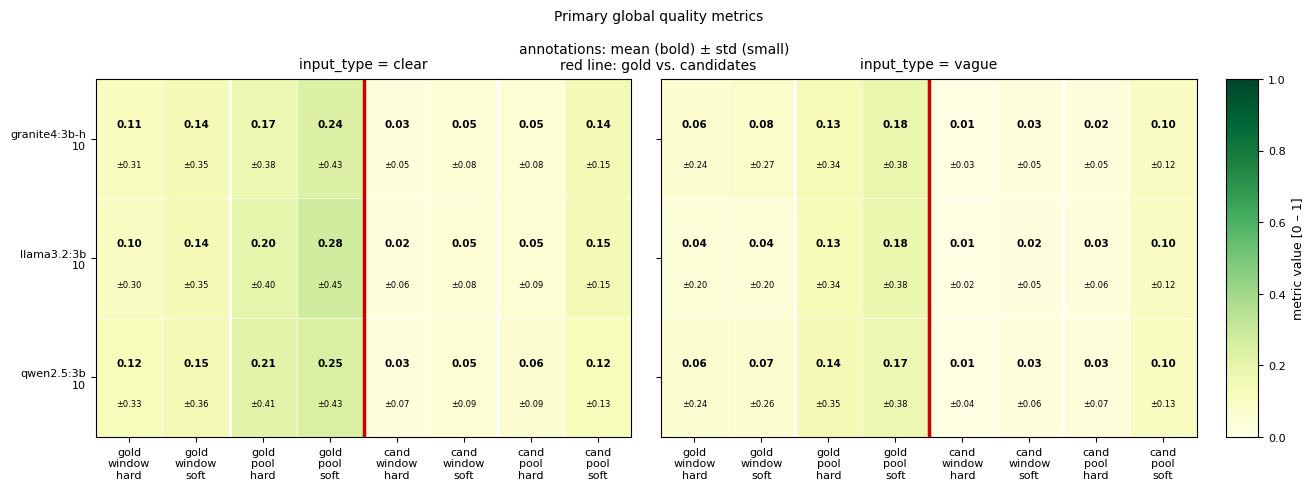

In [17]:
#### Configurations ###############################################################
MODELS  = sorted(global_metrics["model_name"].unique())
WINDOWS = sorted(global_metrics["window_size"].unique())
CONFIGS = [(m, w) for w in WINDOWS for m in MODELS]
CONFIG_LABELS = [f"{m}\n{w}" for m, w in CONFIGS]


QUALITY_STD_COLS = [c + "_std" for c in QUALITY_COLS]

QUALITY_LABELS = [
    "gold\nwindow\nhard", "gold\nwindow\nsoft",
    "gold\npool\nhard",   "gold\npool\nsoft",
    "cand\nwindow\nhard", "cand\nwindow\nsoft",
    "cand\npool\nhard",   "cand\npool\nsoft",
]

# White separators within gold / within cand subgroups
# Red separator between gold and candidates groups
WHITE_SEPARATORS = [1.5, 5.5]
RED_SEPARATOR    = 3.5

INPUT_TYPES      = ["clear", "vague"]

CMAP            = plt.cm.YlGn
VMIN, VMAX      = 0.0, 1.0
TEXT_THRESHOLD  = 0.60

N_ROWS      = len(CONFIGS)
N_COLS_DATA = len(QUALITY_COLS)


def _plot_quality_heatmap(metrics_subset, suptitle, n_sentences=None, low_sample=False):
    """
    Quality heatmap shared by 4.1.1 (global overview) and 4.1.2 (per turn_pos).

    metrics_subset : dataframe with one row per (model_name, window_size, input_type)
                      and the QUALITY_COLS / QUALITY_STD_COLS columns.
    suptitle        : figure title.
    n_sentences     : optional {"clear": n, "vague": n} dict, shown in subplot titles.
    low_sample      : if True, highlight subplot borders in orange (small-sample warning).
    """
    fig = plt.figure(figsize=(15, max(3.5, 0.55 * N_ROWS + 3.0)))
    gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.06], wspace=0.08)

    ax_left  = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)
    ax_cbar  = fig.add_subplot(gs[0, 2])

    heatmap_axes = [ax_left, ax_right]
    last_im = None

    for ax, input_type in zip(heatmap_axes, INPUT_TYPES):
        subset = metrics_subset[metrics_subset["input_type"] == input_type]

        matrix     = []
        matrix_std = []
        for model, window in CONFIGS:
            row = subset[
                (subset["model_name"]  == model) &
                (subset["window_size"] == window)
            ]
            if not row.empty:
                matrix.append([float(row[c].iloc[0]) for c in QUALITY_COLS])
                matrix_std.append([float(row[c].iloc[0]) for c in QUALITY_STD_COLS])
            else:
                matrix.append([float("nan")] * N_COLS_DATA)
                matrix_std.append([float("nan")] * N_COLS_DATA)
        matrix     = np.array(matrix)
        matrix_std = np.array(matrix_std)

        last_im = ax.imshow(matrix, vmin=VMIN, vmax=VMAX, cmap=CMAP, aspect="auto")

        ax.set_xticks(range(N_COLS_DATA))
        ax.set_xticklabels(QUALITY_LABELS, fontsize=8)
        ax.set_yticks(range(N_ROWS))
        ax.set_yticklabels(CONFIG_LABELS, fontsize=8)

        title = f"input_type = {input_type}"
        if n_sentences is not None:
            title += f"  (n_sentences = {n_sentences[input_type]})"
        ax.set_title(title, fontsize=10, pad=8)

        if ax is ax_right:
            plt.setp(ax.get_yticklabels(), visible=False)

        # Numeric annotations: mean (bold) + ±std (smaller, below)
        for i in range(N_ROWS):
            for j in range(N_COLS_DATA):
                val = matrix[i, j]
                std = matrix_std[i, j]
                if not np.isnan(val):
                    text_color = "white" if val > TEXT_THRESHOLD else "black"
                    ax.text(
                        j, i - 0.12, f"{val:.2f}",
                        ha="center", va="center",
                        fontsize=7.5, color=text_color, fontweight="bold",
                    )
                    if not np.isnan(std):
                        ax.text(
                            j, i + 0.22, f"\xb1{std:.2f}",
                            ha="center", va="center",
                            fontsize=6.0, color=text_color,
                        )

        # White separators within gold / within cand subgroups
        for x in WHITE_SEPARATORS:
            ax.axvline(x=x, color="white", lw=2.0)

        # Red separator: gold vs. candidates
        ax.axvline(x=RED_SEPARATOR, color="#cc0000", lw=2.5)

        # Cell grid (minor ticks)
        ax.set_xticks(np.arange(-0.5, N_COLS_DATA, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, N_ROWS, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.5)
        ax.tick_params(which="minor", length=0)

        if low_sample:
            for spine in ax.spines.values():
                spine.set_edgecolor("#E08030")
                spine.set_linewidth(2.5)

    cbar = fig.colorbar(last_im, cax=ax_cbar)
    cbar.set_label("metric value [0 \u2013 1]", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle(suptitle, fontsize=10, y=1.03)

    plt.tight_layout()
    plt.show()


_plot_quality_heatmap(
    global_metrics,
    "Primary global quality metrics\n\n"
    "annotations: mean (bold) \xb1 std (small)  \nred line: gold vs. candidates",
)

#### 4.1.2 Turn point of view

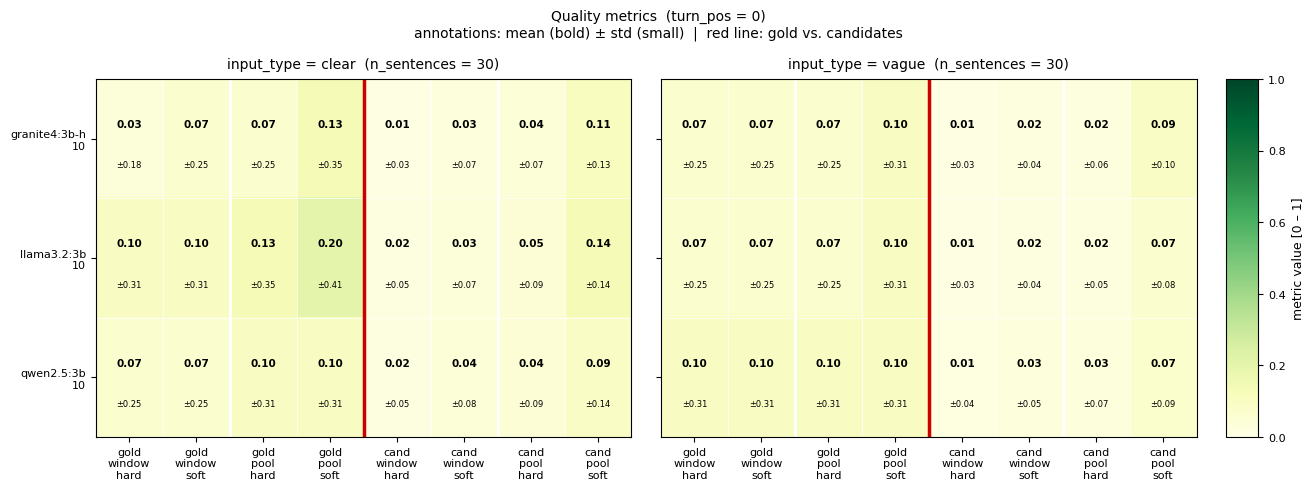

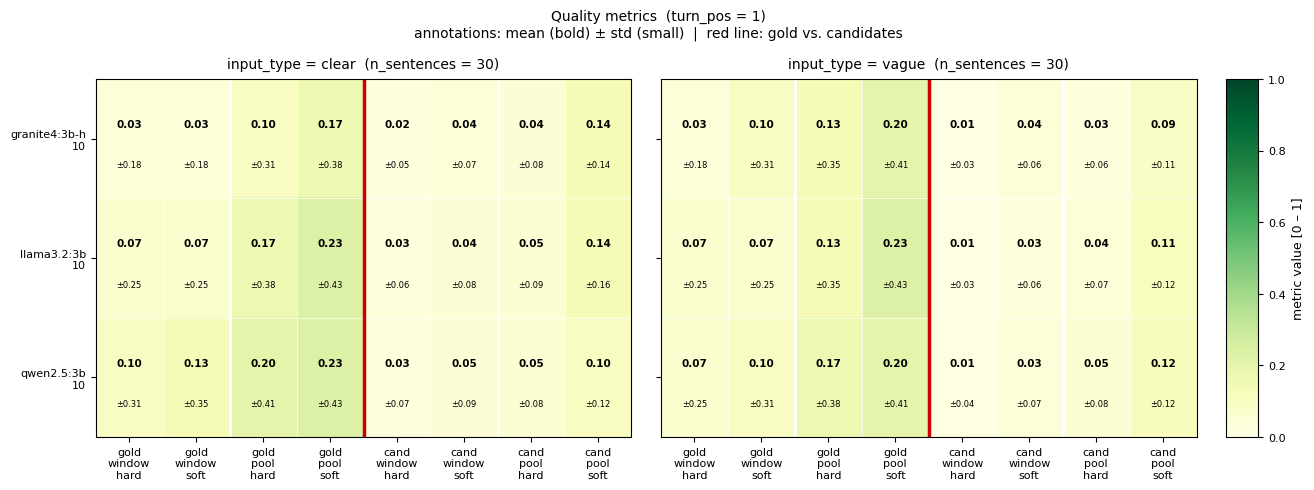

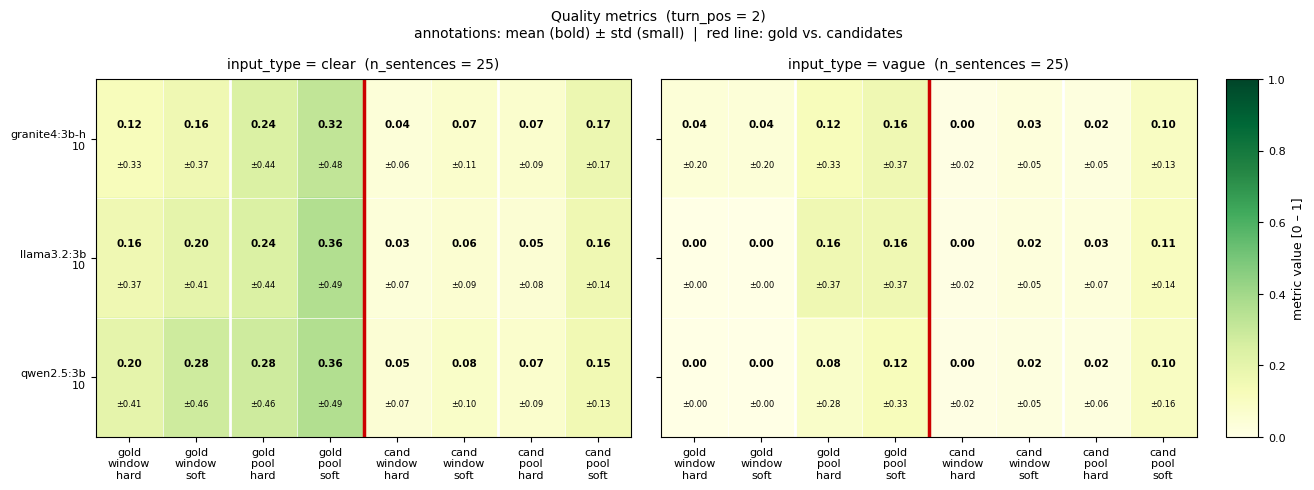

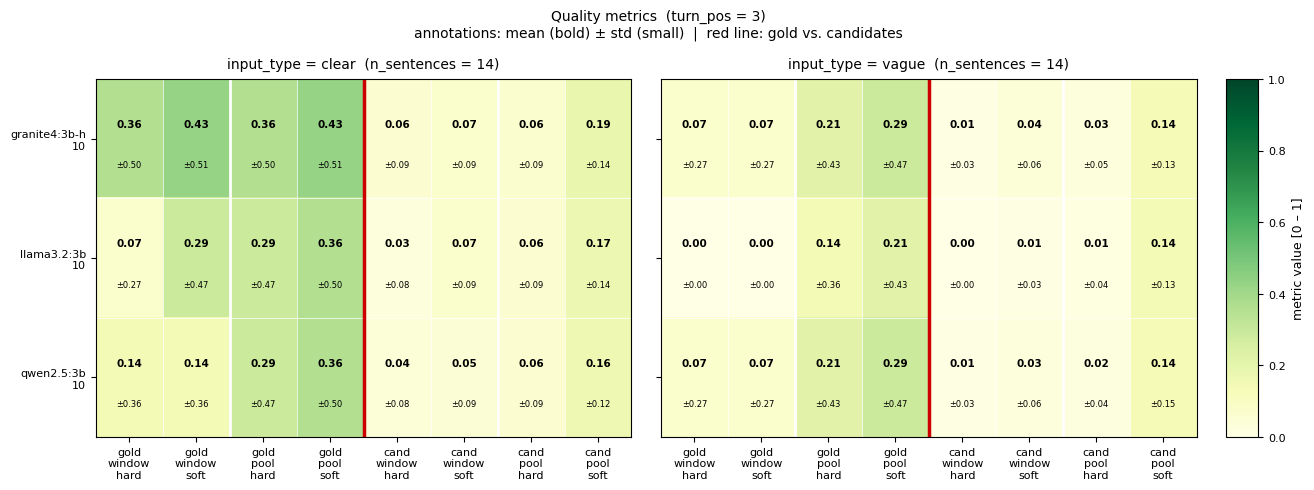

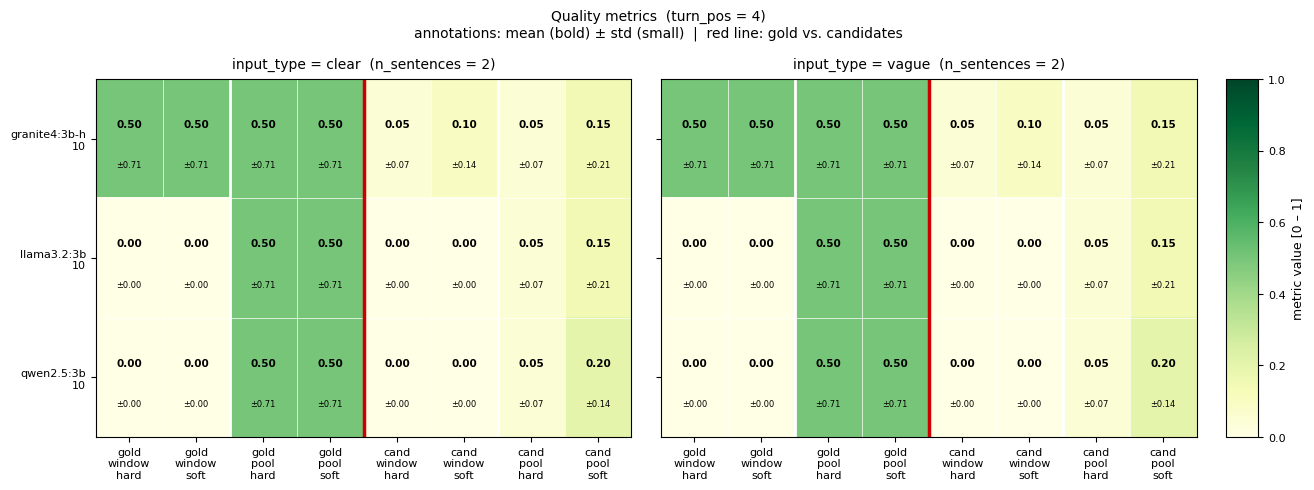

In [18]:
_LOW_SAMPLE_THR = 0   # disable warnings

for t in TURN_POSITIONS:
    subset_all = turn_metrics[turn_metrics["turn_pos"] == t]

    n_clear = int(subset_all.loc[subset_all["input_type"] == "clear", "n_sentences"].max())
    n_vague = int(subset_all.loc[subset_all["input_type"] == "vague", "n_sentences"].max())
    low_sample = max(n_clear, n_vague) < _LOW_SAMPLE_THR

    _plot_quality_heatmap(
        subset_all,
        f"Quality metrics  (turn_pos = {t})\n"
        "annotations: mean (bold) \xb1 std (small)  |  red line: gold vs. candidates",
        n_sentences={"clear": n_clear, "vague": n_vague},
        low_sample=low_sample,
    )

### 4.2 Retrieve & ranking

#### 4.2.1 How much the ranker is losing along the way?

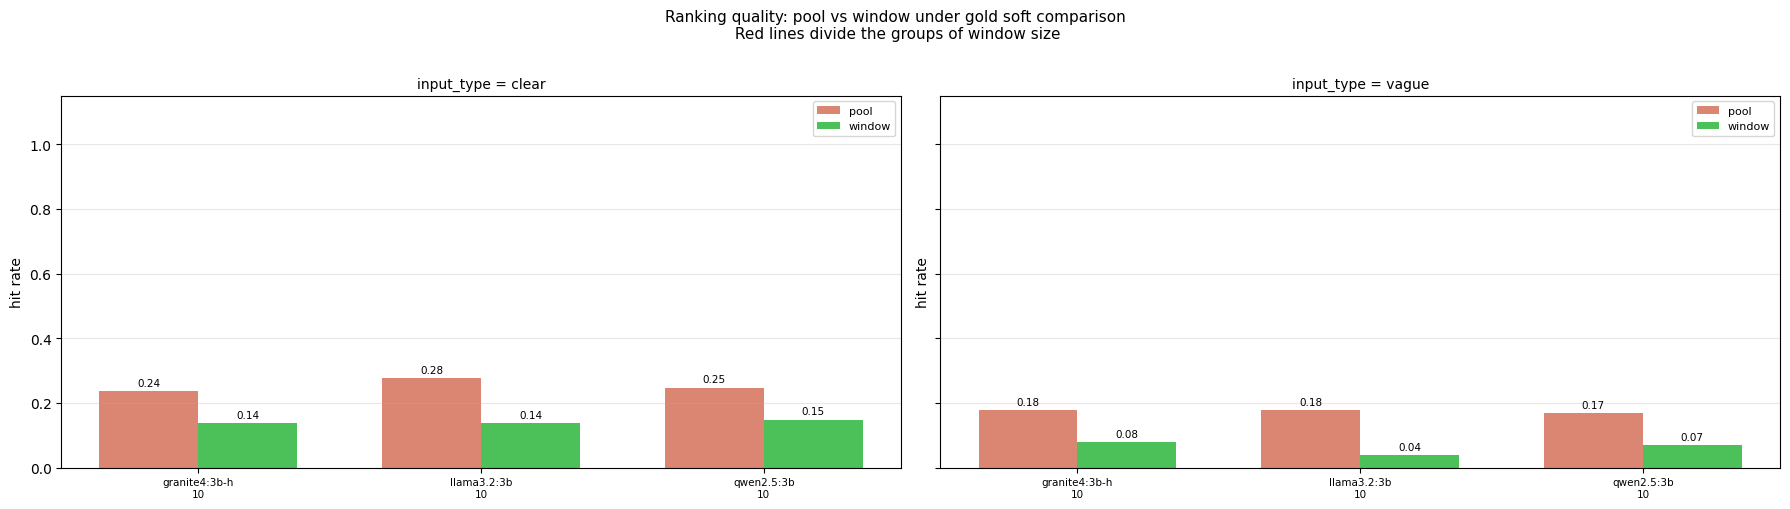

In [19]:
def _grouped_bar_by_config(ax, subset, cols, labels, colors, configs, config_labels,
                            n_per_group, width=0.35, ylabel="hit rate", ylim=(0, 1.15)):
    """
    Shared scaffolding for "one bar group per (model, window) config" charts:
    draws `len(cols)` side-by-side bars per config, numeric labels above each bar,
    and red dashed separators between groups of `n_per_group` configs (e.g. models).
    Returns nothing; the caller still sets title/legend if it wants extra control.
    """
    x = np.arange(len(configs))

    for i, (col, label, color) in enumerate(zip(cols, labels, colors)):
        vals = []
        for model, window in configs:
            row = subset[(subset["model_name"] == model) & (subset["window_size"] == window)]
            vals.append(row[col].values[0] if not row.empty else float("nan"))
        offset = (i - (len(cols) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, fontsize=7.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel(ylabel)

    for sep in range(n_per_group, len(configs), n_per_group):
        ax.axvline(x=sep - 0.5, color="#cc0000", lw=1.5, linestyle="--", zorder=3)

    return x


fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

BAR_COLS   = ["gold_pool_soft", "gold_window_soft"]
BAR_LABELS = ["pool", "window"]
COLORS_BAR = ["#D5715B", "#2EB63C"]

N_MODELS = len(MODELS)

for ax, input_type in zip(axes, ["clear", "vague"]):
    subset = global_metrics[global_metrics["input_type"] == input_type]
    _grouped_bar_by_config(ax, subset, BAR_COLS, BAR_LABELS, COLORS_BAR,
                            CONFIGS, CONFIG_LABELS, N_MODELS)
    ax.set_title(f"input_type = {input_type}", fontsize=10)

fig.suptitle("Ranking quality: pool vs window under gold soft comparison"
             "\n Red lines divide the groups of window size", 
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In general here we can find worse results on the window with respect to the round robin weighted method, while the pool is the same.

#### 4.2.2 Where the gold pictogram actually lands inside the ranked pool, and what fraction of the time it gets buried below the window cut?

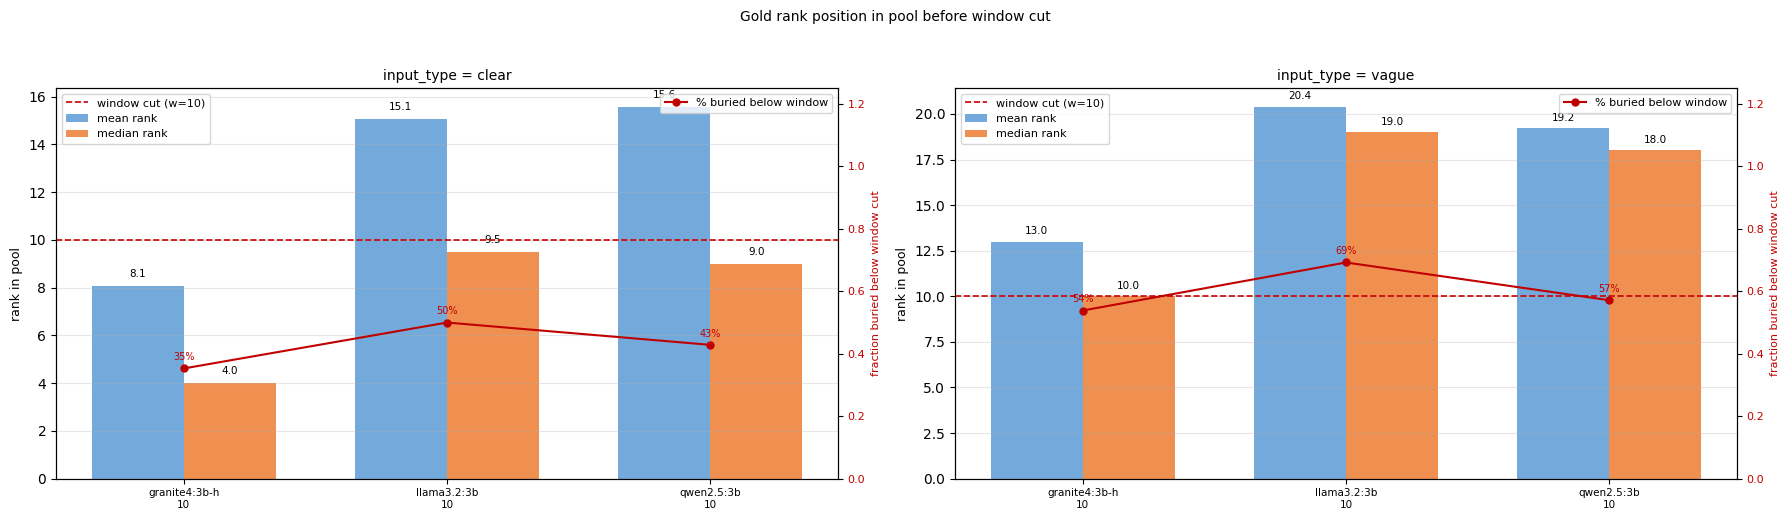

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

RANK_COLORS = {"gold_rank_mean": "#5B9BD5", "gold_rank_median": "#ED7D31"}
x     = np.arange(len(CONFIGS))
width = 0.35

for ax, input_type in zip(axes, ["clear", "vague"]):
    subset = global_metrics[global_metrics["input_type"] == input_type]

    for i, (col, label, color) in enumerate(zip(
        ["gold_rank_mean", "gold_rank_median"],
        ["mean rank",      "median rank"],
        ["#5B9BD5",        "#ED7D31"],
    )):
        vals = []
        for model, window in CONFIGS:
            row = subset[(subset["model_name"] == model) & (subset["window_size"] == window)]
            vals.append(float(row[col].iloc[0]) if not row.empty else float("nan"))
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}",
                    ha="center", va="bottom", fontsize=7.5,
                )

    ax2 = ax.twinx()
    pct_vals = []
    for model, window in CONFIGS:
        row = subset[(subset["model_name"] == model) & (subset["window_size"] == window)]
        pct_vals.append(float(row["gold_rank_pct_above_w"].iloc[0]) if not row.empty else float("nan"))

    ax2.plot(x, pct_vals, color="#C00000", marker="o", linewidth=1.5,
             markersize=5, label="% buried below window", zorder=5)
    for xi, val in zip(x, pct_vals):
        if not np.isnan(val):
            ax2.text(xi, val + 0.02, f"{val:.0%}",
                     ha="center", va="bottom", fontsize=7, color="#C00000")
    ax2.set_ylim(0, 1.25)
    ax2.set_ylabel("fraction buried below window cut", fontsize=8, color="#C00000")
    ax2.tick_params(axis="y", labelcolor="#C00000", labelsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    w_val = WINDOWS[0] if len(WINDOWS) == 1 else None  
    if w_val is not None:
        ax.axhline(y=w_val, color="#cc0000", lw=1.2, linestyle="--",
                   label=f"window cut (w={w_val})", zorder=3)

    N_MODELS = len(MODELS)
    for sep in range(N_MODELS, len(CONFIGS), N_MODELS):
        ax.axvline(x=sep - 0.5, color="#cc0000", lw=1.5, linestyle="--", zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(CONFIG_LABELS, fontsize=7.5)
    ax.set_ylabel("rank in pool", fontsize=9)
    ax.set_title(f"input_type = {input_type}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Gold rank position in pool before window cut",
    fontsize=10, y=1.03,
)
plt.tight_layout()
plt.show()

Here we can observe why sequential blocks is worse, cannot prioritize some golds as they are probably obtained by expansions of secondary concepts wrote by the model. It does not look at the window, the reason why it still performs not that bad is probably the model inner ranking skill when giving candidate concepts.

#### 4.2.3 pool vs window comparison, but using the annotation-independent concept-text match instead of gold

The gap between this and the gold-based version tells us how much of the "miss" is really just annotation noise.

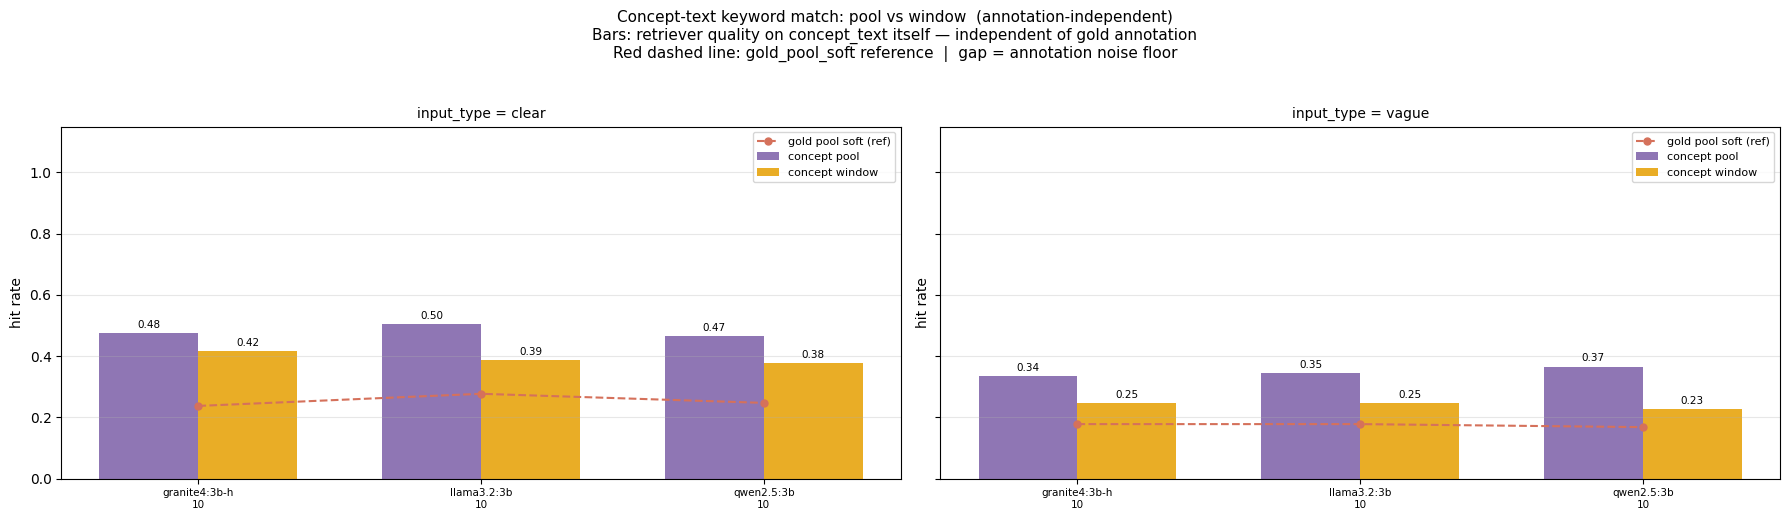

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

BAR_COLS_CM   = ["concept_pool_mean",   "concept_window_mean"]
BAR_LABELS_CM = ["concept pool",        "concept window"]
COLORS_CM     = ["#7B5EA7",             "#E69F00"]

for ax, input_type in zip(axes, ["clear", "vague"]):
    subset = global_metrics[global_metrics["input_type"] == input_type]
    x = _grouped_bar_by_config(ax, subset, BAR_COLS_CM, BAR_LABELS_CM, COLORS_CM,
                                CONFIGS, CONFIG_LABELS, N_MODELS)

    # Overlay gold_pool_soft as a reference line per config
    gold_vals = []
    for model, window in CONFIGS:
        row = subset[(subset["model_name"] == model) & (subset["window_size"] == window)]
        gold_vals.append(row["gold_pool_soft"].values[0] if not row.empty else float("nan"))
    ax.plot(x, gold_vals, color="#D5715B", marker="o", linewidth=1.5,
            markersize=5, linestyle="--", label="gold pool soft (ref)", zorder=5)
    ax.legend(fontsize=8)  # redraw legend to include the reference line
    ax.set_title(f"input_type = {input_type}", fontsize=10)

fig.suptitle(
    "Concept-text keyword match: pool vs window  (annotation-independent)\n"
    "Bars: retriever quality on concept_text itself — independent of gold annotation\n"
    "Red dashed line: gold_pool_soft reference  |  gap = annotation noise floor",
    fontsize=11, y=1.03,
)
plt.tight_layout()
plt.show()

#### 4.2.4 pool lift over random baseline

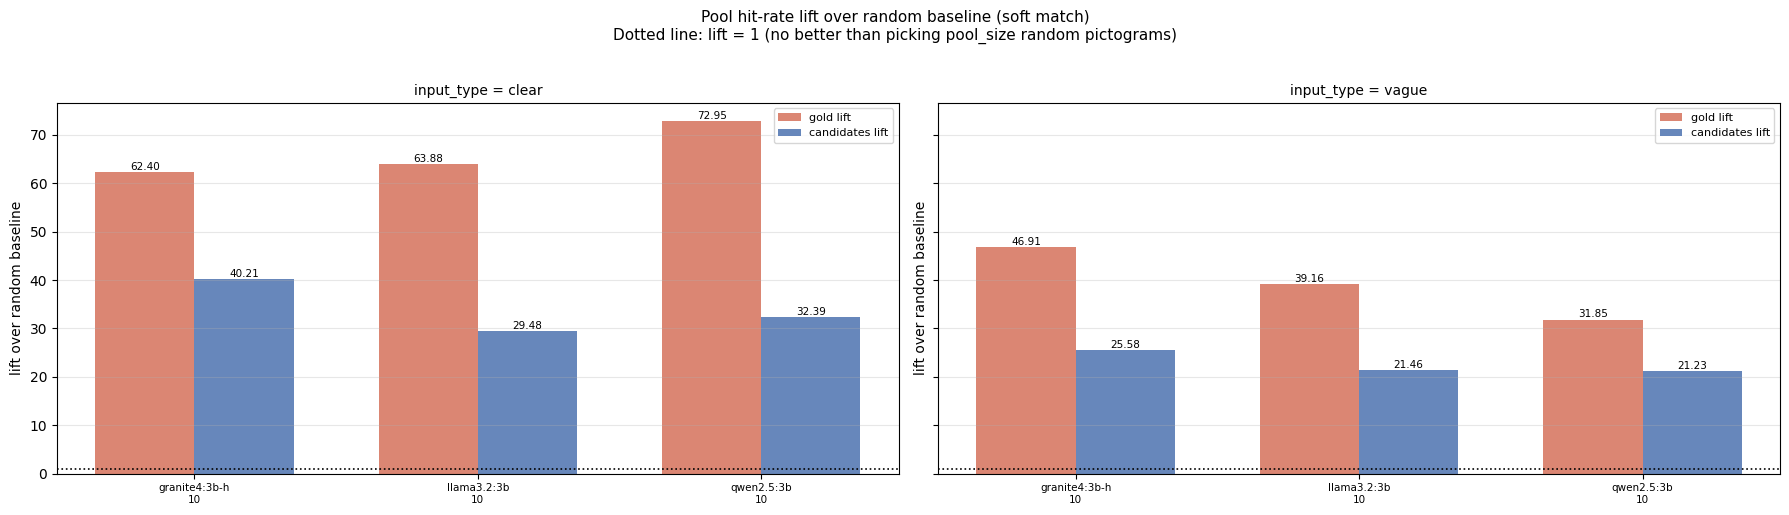

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

LIFT_COLS   = ["pool_lift_gold_soft", "pool_lift_cand_soft"]
LIFT_LABELS = ["gold lift", "candidates lift"]
COLORS_LIFT = ["#D5715B", "#4C72B0"]

for ax, input_type in zip(axes, ["clear", "vague"]):
    subset = global_metrics[global_metrics["input_type"] == input_type]
    _grouped_bar_by_config(ax, subset, LIFT_COLS, LIFT_LABELS, COLORS_LIFT,
                            CONFIGS, CONFIG_LABELS, N_MODELS,
                            ylabel="lift over random baseline", ylim=None)
    ax.axhline(y=1.0, color="black", lw=1.2, linestyle=":", zorder=2)
    ax.set_title(f"input_type = {input_type}", fontsize=10)

fig.suptitle("Pool hit-rate lift over random baseline (soft match)\n"
             "Dotted line: lift = 1 (no better than picking pool_size random pictograms)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

#### 4.2.5 gold vs. candidates gap

`gold_* > cand_*` was already visible in raw terms back in [4.1.1](#411-global-comparison-quality-metrics-by-model-window-size-and-input-type), but that comparison is structurally biased: `gold_*` is a binary hit, `cand_*` is a fraction averaged over a longer list, so `gold_* > cand_*` doesn't tell us anything about the retriever. 

The two cells below isolate the *real* gap from two angles: first by putting gold and candidates on the same per-item footing (removing the binary-vs-fraction artifact), then by checking directly how semantically related the annotator's non-gold candidates are to the gold in the first place.

In [23]:
n_candidates = df["candidate_ids"].apply(len)

print(f"Mean pool size       : {pool_size.mean():.2f} ± {pool_size.std():.2f}")
print(f"Mean # candidate_ids : {n_candidates.mean():.2f} ± {n_candidates.std():.2f}")

def per_item_hit_prob(df, target_col, source_col, method):
    """
    P(a single item in `source_col` is equivalent to *something* in `target_col`),
    pooled across all rows.
    """
    total_items, total_hits = 0, 0
    for _, r in df.iterrows():
        items = r[source_col] if isinstance(r[source_col], list) else [r[source_col]]
        targets = r[target_col]
        total_items += len(items)
        total_hits += sum(any(pict_equiv(it, t, method) for t in targets) for it in items)
    return total_hits / total_items if total_items else float("nan")

rows_clear = df[df["input_type"] == "clear"]
rows_vague = df[df["input_type"] == "vague"]

summary = []
for label, subset in [("clear", rows_clear), ("vague", rows_vague)]:
    gold_p = per_item_hit_prob(subset, "pool_ids", "gold_id", "soft")
    cand_p = per_item_hit_prob(subset, "pool_ids", "candidate_ids", "soft")
    summary.append({
        "input_type": label,
        "gold_hit_prob_per_item": round(gold_p, 3),
        "cand_hit_prob_per_item": round(cand_p, 3),
        "ratio_gold_over_cand":   round(gold_p / cand_p, 2) if cand_p else float("nan"),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

Mean pool size       : 75.29 ± 33.14
Mean # candidate_ids : 10.00 ± 0.00


,input_type,gold_hit_prob_per_item,cand_hit_prob_per_item,ratio_gold_over_cand
0,clear,0.254,0.137,1.86
1,vague,0.175,0.102,1.72


Non-gold candidates checked : 909
Mean soft-score to gold     : 0.037 ± 0.106
Median soft-score to gold   : 0.000

Fraction above soft threshold (0.3)        : 3.1%
Fraction completely unrelated (score == 0) : 52.8%


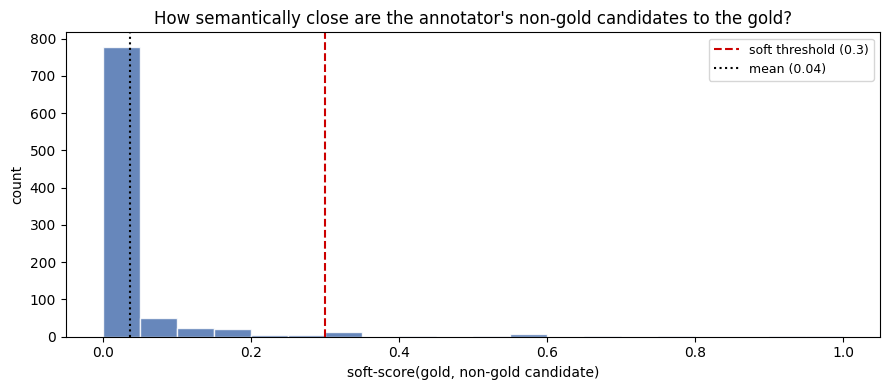

In [24]:
candidate_rows = (
    df[["row_idx", "turn_pos", "gold_id", "candidate_ids"]]
    .drop_duplicates(subset=["row_idx", "turn_pos"])
    .copy()
)

def non_gold_scores(row):
    gid = int(row["gold_id"])
    return [
        _soft_score(gid, int(cid))
        for cid in row["candidate_ids"]
        if int(cid) != gid
    ]

candidate_rows["non_gold_scores"] = candidate_rows.apply(non_gold_scores, axis=1)
all_non_gold_scores = [s for row in candidate_rows["non_gold_scores"] for s in row]

non_gold_arr = np.array(all_non_gold_scores)

print(f"Non-gold candidates checked : {len(non_gold_arr)}")
print(f"Mean soft-score to gold     : {non_gold_arr.mean():.3f} ± {non_gold_arr.std():.3f}")
print(f"Median soft-score to gold   : {np.median(non_gold_arr):.3f}")
print()
print(f"Fraction above soft threshold ({_SOFT_THRESHOLD})        : {(non_gold_arr >= _SOFT_THRESHOLD).mean():.1%}")
print(f"Fraction completely unrelated (score == 0) : {(non_gold_arr == 0).mean():.1%}")

candidate_rows["position_scores"] = candidate_rows.apply(
    lambda r: list(enumerate(
        s for cid, s in zip(
            [c for c in r["candidate_ids"] if int(c) != int(r["gold_id"])],
            r["non_gold_scores"]
        )
    )),
    axis=1,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(non_gold_arr, bins=20, range=(0, 1), color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(x=_SOFT_THRESHOLD, color="#cc0000", linestyle="--", lw=1.5,
           label=f"soft threshold ({_SOFT_THRESHOLD})")
ax.axvline(x=non_gold_arr.mean(), color="black", linestyle=":", lw=1.5,
           label=f"mean ({non_gold_arr.mean():.2f})")
ax.set_xlabel("soft-score(gold, non-gold candidate)")
ax.set_ylabel("count")
ax.set_title("How semantically close are the annotator's non-gold candidates to the gold?")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Resolve & tool usage

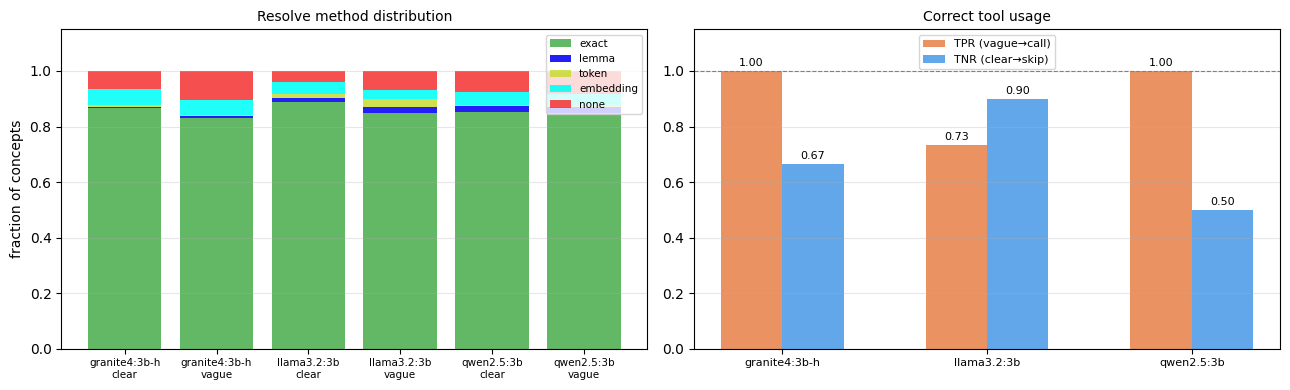

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resolve_df = (
    df[["model_name", "input_type", "resolve_methods"]]
    .explode("resolve_methods")
    .groupby(["model_name", "input_type"])["resolve_methods"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

RESOLVE_METHODS = ["exact", "lemma", "token", "embedding", "none"]
RESOLVE_METHODS = [m for m in RESOLVE_METHODS if m in resolve_df.columns]
RESOLVE_COLORS  = ["#4CAF50", "#0400F5", "#C9DC39", "#00FFF7", "#F43636"]

resolve_configs = [
    (row["model_name"], row["input_type"])
    for _, row in resolve_df.iterrows()
]
resolve_labels = [f"{m}\n{it}" for m, it in resolve_configs]
x_r = np.arange(len(resolve_labels))

bottom = np.zeros(len(resolve_labels))
ax = axes[0]
for method, color in zip(RESOLVE_METHODS, RESOLVE_COLORS):
    vals = resolve_df[method].values if method in resolve_df.columns else np.zeros(len(resolve_labels))
    ax.bar(x_r, vals, bottom=bottom, label=method, color=color, alpha=0.88)
    bottom += vals

ax.set_xticks(x_r)
ax.set_xticklabels(resolve_labels, fontsize=7.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("fraction of concepts")
ax.set_title("Resolve method distribution", fontsize=10)
ax.legend(fontsize=7.5, loc="upper right")
ax.grid(axis="y", alpha=0.3)

# ── Right: tool usage TPR / TNR by model ─────────────────────────────────────
ax = axes[1]
tool_rows = []
for model in MODELS:
    m_first = (df["turn_pos"] == 0) & (df["model_name"] == model)
    tpr = df.loc[m_first & (df["input_type"] == "vague"), "needs_context"].mean()
    tnr = (~df.loc[m_first & (df["input_type"] == "clear"), "needs_context"]).mean()
    tool_rows.append({"model": model, "TPR (vague→call)": tpr, "TNR (clear→skip)": tnr})

tool_df = pd.DataFrame(tool_rows)
x_t = np.arange(len(MODELS))
for i, (col, color) in enumerate(zip(
    ["TPR (vague→call)", "TNR (clear→skip)"],
    ["#E8834C", "#4C9BE8"]
)):
    offset = (i - 0.5) * 0.3
    bars = ax.bar(x_t + offset, tool_df[col], 0.3, label=col, color=color, alpha=0.88)
    for bar, val in zip(bars, tool_df[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_t)
ax.set_xticklabels(MODELS, fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_title("Correct tool usage", fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.axhline(1.0, color="grey", lw=0.8, linestyle="--")

# fig.suptitle("Resolve diagnostics & tool usage", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Latency

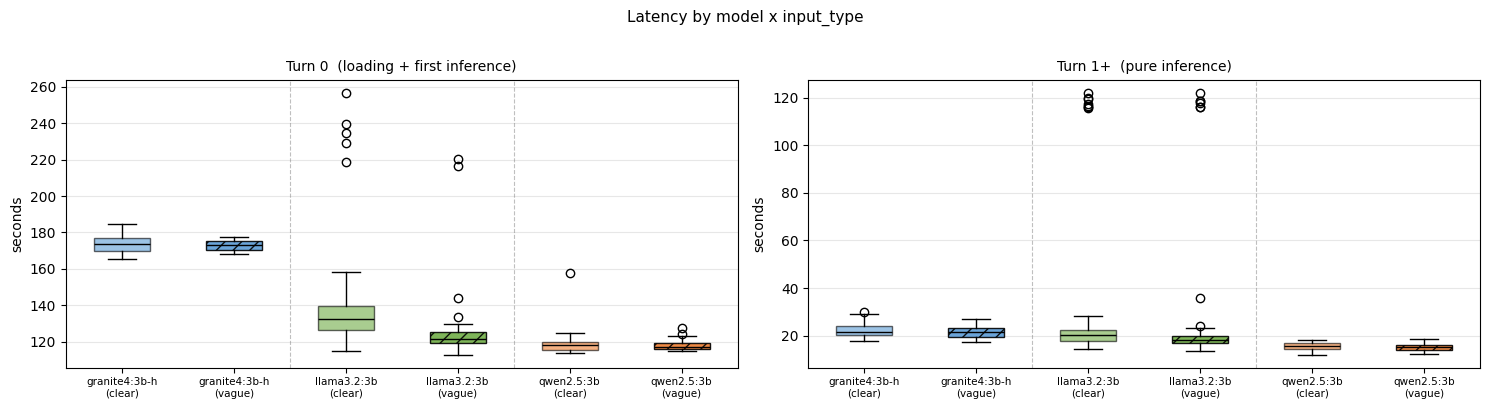

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=False)

MODEL_COLORS = ["#5B9BD5", "#70AD47", "#ED7D31"]
ITYPE_ALPHA  = {"clear": 0.60, "vague": 0.90}    
ITYPE_HATCH  = {"clear": "",   "vague": "//"}    

for ax, (turn_filter, title) in zip(axes, [
    (df["turn_pos"] == 0, "Turn 0  (loading + first inference)"),
    (df["turn_pos"] >  0, "Turn 1+  (pure inference)"),
]):
    groups, tick_labels, colors, alphas, hatches = [], [], [], [], []
    for m, color in zip(MODELS, MODEL_COLORS):
        for itype in ["clear", "vague"]:
            mask = turn_filter & (df["model_name"] == m) & (df["input_type"] == itype)
            groups.append(df.loc[mask, "turn_time_s"].values)
            tick_labels.append(f"{m}\n({itype})")
            colors.append(color)
            alphas.append(ITYPE_ALPHA[itype])
            hatches.append(ITYPE_HATCH[itype])

    bp = ax.boxplot(groups, labels=tick_labels, patch_artist=True,
                    medianprops={"color": "black"})
    for patch, color, alpha, hatch in zip(bp["boxes"], colors, alphas, hatches):
        patch.set_facecolor(color)
        patch.set_alpha(alpha)
        patch.set_hatch(hatch)

    for sep in range(len(["clear", "vague"]), len(groups), len(["clear", "vague"])):
        ax.axvline(x=sep + 0.5, color="grey", lw=0.8, linestyle="--", alpha=0.5)

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("seconds")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelsize=7.5)

fig.suptitle("Latency by model x input_type", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 4.5 Sentence difficulty

This big cells groups the metrics in 4.1 but per input sentence, in this way we look for correlation between mistakes and sentences. When a sentence never got a hit in any configuration we outline it in red, this requires further analysis.

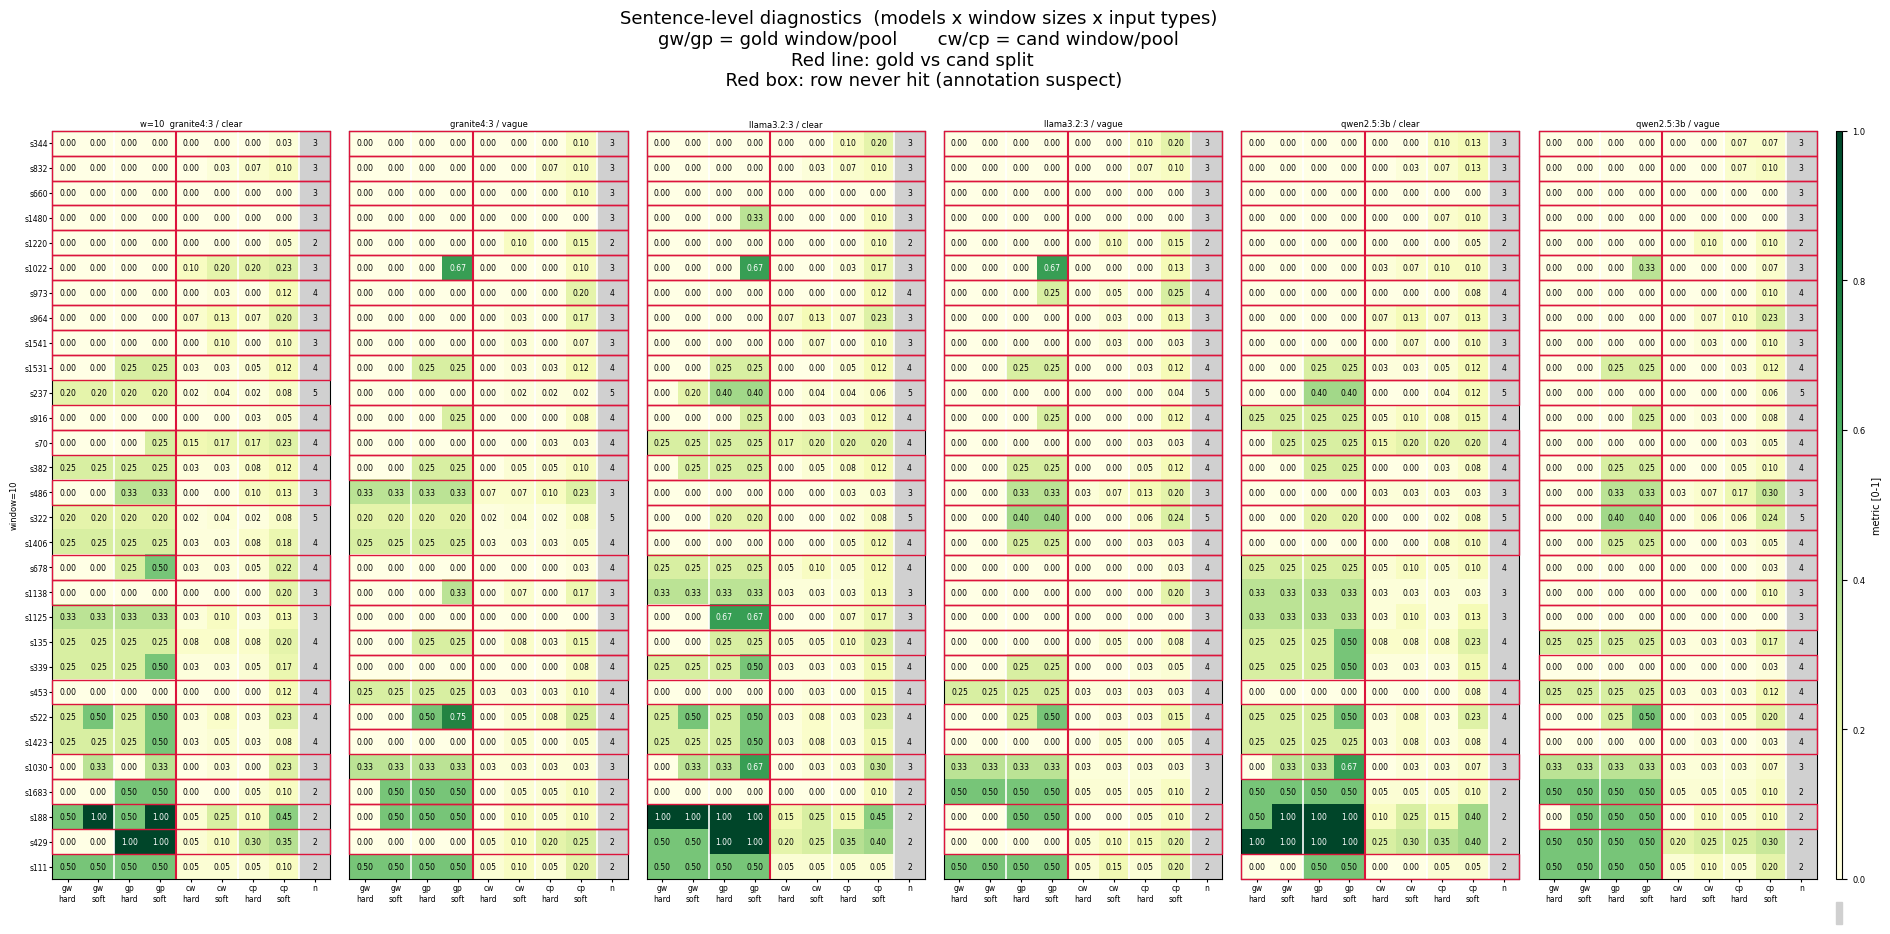

In [27]:
METRIC_COLS = [
    "gold_window_hard_mean",
    "gold_window_soft_mean",
    "gold_pool_hard_mean",
    "gold_pool_soft_mean",
    "cand_window_hard_mean",
    "cand_window_soft_mean",   
    "cand_pool_hard_mean",
    "cand_pool_soft_mean",     
]
METRIC_LABELS = [
    "gw\nhard", "gw\nsoft",
    "gp\nhard", "gp\nsoft",
    "cw\nhard", "cw\nsoft",
    "cp\nhard", "cp\nsoft",
]
NC_COL   = "n_concepts"
NC_LABEL = "n"

ALL_COLS    = METRIC_COLS + [NC_COL]
ALL_LABELS  = METRIC_LABELS + [NC_LABEL]
N_COLS_DATA = len(ALL_COLS)

GROUP_SEP = [1.5, 3.5, 5.5, 7.5]
RED_SEP   = 4.0

CMAP_METRIC    = plt.cm.YlGn
TEXT_THRESHOLD = 0.55
NC_BG_COLOR    = "#d0d0d0"
RED_SEP_COLOR  = "crimson"

MODELS      = sorted(global_metrics["model_name"].unique())
WINDOWS     = sorted(global_metrics["window_size"].unique())
INPUT_TYPES = ["clear", "vague"]

N_GRID_ROWS = len(WINDOWS)
N_GRID_COLS = len(MODELS) * len(INPUT_TYPES)

GRID_COL_CONFIGS = [(m, it) for m in MODELS for it in INPUT_TYPES]
GRID_COL_LABELS  = [f"{m}\n{it}" for m, it in GRID_COL_CONFIGS]

row_order_per_window = {}
for window in WINDOWS:
    w_sub = sentence_stats[sentence_stats["window_size"] == window]
    order = (
        w_sub.groupby("row_idx")["gold_window_hard_mean"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    row_order_per_window[window] = order

max_sentences = max(len(order) for order in row_order_per_window.values())

CELL_W = 1.8
CELL_H = 0.22
CBAR_W = 0.25

fig_w = CELL_W * N_GRID_COLS + CBAR_W + 0.5
fig_h = CELL_H * max_sentences * N_GRID_ROWS + 1.5

fig = plt.figure(figsize=(2*fig_w, 1.2*fig_h))

gs = gridspec.GridSpec(
    N_GRID_ROWS, N_GRID_COLS + 1,
    figure=fig,
    width_ratios=[1] * N_GRID_COLS + [CBAR_W / (CELL_W * N_GRID_COLS)],
    hspace=0.55,
    wspace=0.08,
)

ax_cbar = fig.add_subplot(gs[:, N_GRID_COLS])
last_im = None

row_anchor_ax = {row_i: None for row_i in range(N_GRID_ROWS)}

for row_i, window in enumerate(WINDOWS):
    shared_row_idx_order = row_order_per_window[window]

    for col_i, (model, input_type) in enumerate(GRID_COL_CONFIGS):

        ax = fig.add_subplot(gs[row_i, col_i])

        cell_data = sentence_stats[
            (sentence_stats["model_name"]  == model) &
            (sentence_stats["window_size"] == window) &
            (sentence_stats["input_type"]  == input_type)
        ].set_index("row_idx")

        sub = cell_data.reindex(shared_row_idx_order).reset_index()

        N_S        = len(sub)
        row_labels = [f"s{int(idx)}" for idx in shared_row_idx_order]

        has_any_data = sub[METRIC_COLS[0]].notna().any() if N_S > 0 else False

        if has_any_data:
            anchor = row_anchor_ax[row_i]
            if anchor is not None:
                ax.sharey(anchor)
            else:
                row_anchor_ax[row_i] = ax

        matrix = np.full((N_S, N_COLS_DATA), np.nan)
        for j, col in enumerate(METRIC_COLS):
            matrix[:, j] = sub[col].values.astype(float)
        nc_vals = sub[NC_COL].values.astype(float)

        im = ax.imshow(
            matrix[:, :len(METRIC_COLS)],
            vmin=0, vmax=1, cmap=CMAP_METRIC,
            aspect="auto",
            extent=[-0.5, len(METRIC_COLS) - 0.5, N_S - 0.5, -0.5],
        )
        last_im = im

        nc_x = len(METRIC_COLS)
        ax.axvspan(nc_x - 0.5, nc_x + 0.5, color=NC_BG_COLOR, zorder=0)

        for i in range(N_S):
            for j in range(len(METRIC_COLS)):
                val = matrix[i, j]
                if not np.isnan(val):
                    fg = "white" if val > TEXT_THRESHOLD else "black"
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=5.5, color=fg, clip_on=True)
            if not np.isnan(nc_vals[i]):
                ax.text(nc_x, i, f"{int(nc_vals[i])}", ha="center", va="center",
                        fontsize=5.5, color="black", clip_on=True)

        for xv in GROUP_SEP:
            ax.axvline(x=xv, color="white", lw=1.2, zorder=3)

        ax.axvline(x=RED_SEP - 0.5, color=RED_SEP_COLOR, lw=1.5, zorder=4)

        for i in range(N_S):
            val = sub["gold_window_hard_mean"].iloc[i]
            if pd.notna(val) and val == 0.0:
                ax.add_patch(mpatches.Rectangle(
                    (-0.5, i - 0.5), N_COLS_DATA, 1,
                    fill=False, edgecolor="crimson", lw=1.0, zorder=5, clip_on=False,
                ))

        ax.set_xlim(-0.5, N_COLS_DATA - 0.5)
        ax.set_ylim(N_S - 0.5, -0.5)

        ax.set_xticks(range(N_COLS_DATA))
        ax.set_xticklabels(ALL_LABELS, fontsize=5.5, rotation=0)
        ax.tick_params(axis="x", length=2, pad=1)

        if col_i == 0:
            ax.set_yticks(range(N_S))
            ax.set_yticklabels(row_labels, fontsize=5.5)
            ax.tick_params(axis="y", length=2, pad=1)
        else:
            ax.tick_params(axis="y", labelleft=False, length=0)

        title_top = f"w={window}" if col_i == 0 else ""
        title_top += f"  {model[:10]} / {input_type}"
        ax.set_title(title_top.strip(), fontsize=6, pad=3)

        if col_i == 0:
            ax.set_ylabel(f"window={window}", fontsize=6, labelpad=4)

cbar = fig.colorbar(last_im, cax=ax_cbar)
cbar.set_label("metric [0-1]", fontsize=7)
cbar.ax.tick_params(labelsize=6)

ax_cbar.add_patch(mpatches.Rectangle(
    (0, -0.06), 1, 0.03,
    transform=ax_cbar.transAxes,
    color=NC_BG_COLOR, clip_on=False,
))

fig.suptitle(
    f"Sentence-level diagnostics  (models x window sizes x input types)\n"
    f"gw/gp = gold window/pool       cw/cp = cand window/pool\n"
    f"Red line: gold vs cand split  \n  Red box: row never hit (annotation suspect)",
    fontsize=13, y=1.005,
)

plt.show()

In [28]:
# Compute the exact data that are visisble in the plot to cite them in the note

n_total_turns = len(df)
always_zero_concepts = df[df["row_idx"].isin(always_zero)]
n_always_zero_turns = len(always_zero_concepts)
print(f"There are {len(always_zero)} always-0 sentences, that are: {always_zero}")
print(f"The always-0 sentences account for {n_always_zero_turns} concepts/turns, "
      f"{100 * n_always_zero_turns / n_total_turns:.1f}% of the total {n_total_turns} turns.")

n_concepts_per_row = sentence_stats.drop_duplicates("row_idx").set_index("row_idx")["n_concepts"]
print(f"\nMean n_concepts: \
        \n\t• always-0 sentences: {n_concepts_per_row.loc[always_zero].mean():.2f} \
        \n\t• all sentences     : {n_concepts_per_row.mean():.2f}")

gp_for_always_zero = (
    sentence_stats[sentence_stats["row_idx"].isin(always_zero)]
    .groupby("row_idx")["gold_pool_soft_mean"].max()
)
n_pool_also_zero = (gp_for_always_zero == 0.0).sum()
n_pool_recoverable = (gp_for_always_zero > 0.0).sum()
print(f"\nOf these: \
        \n\t- gold is unreachable even in the full pool (gp=0) for {n_pool_also_zero} sentences \
        \n\t- gold is in the pool but missed the window (gp>0) for {n_pool_recoverable} sentences")

There are 10 always-0 sentences, that are: [344, 660, 832, 964, 973, 1022, 1220, 1480, 1531, 1541]
The always-0 sentences account for 186 concepts/turns, 30.7% of the total 606 turns.

Mean n_concepts:         
	• always-0 sentences: 3.10         
	• all sentences     : 3.37

Of these:         
	- gold is unreachable even in the full pool (gp=0) for 6 sentences         
	- gold is in the pool but missed the window (gp>0) for 4 sentences


## 5. Evaluation dataset audit

After noticing that some sentences scored zero no matter which model or input type we tried, we have to ask ourselves if it is this a retriever problem (most of them do not show gold hits and only strange candidates hit), or is the ground truth itself off? 

In order to inspect it, in this section we will look to the annotatio-invariant metrics that we already showed in sections 4.* and we will also visualize the actual predictions and golds to better have an idea of what we are talking about.

In [29]:
# Here we extract the problematic rows
always_zero_hard_ids = (
    sentence_stats
    .groupby("row_idx")["gold_window_hard_mean"]
    .max()
    .pipe(lambda s: s[s == 0.0])
    .index
    .tolist()
)
always_zero_soft_ids = (
    sentence_stats
    .groupby("row_idx")["gold_window_soft_mean"]
    .max()
    .pipe(lambda s: s[s == 0.0])
    .index
    .tolist()
)

### 5.1 Inspect visually the gold_id, the window and the pool [**DEBUG SECTION**]

In [30]:
# Configuration of following cell

# NOTE: choose if you want to inspect hard or soft errors
# ROW_IDX_LIST = always_zero_hard_ids
ROW_IDX_LIST = always_zero_soft_ids
print(f"There are {len(ROW_IDX_LIST)} suspicious rows to inspect")

# NOTE: choose if you want to focus on a certain type of input
INPUT_TYPES = [
    "clear", 
    # "vague"
]

There are 10 suspicious rows to inspect


In [31]:
# PICT_DIR = Path("./../../../app/datasets/pictograms")

# ROLE_COLORS = {
#     "gold":       "#d62728",   
#     "candidates": "#1f77b4",   
#     "predicted":  "#2ca02c",   
# }
# ROLE_ORDER = ["gold", "candidates", "predicted"]

# THUMB_PX      = 64
# BORDER_LW     = 2.6
# ID_FONTSIZE   = 7.5     
# SECTION_FS    = 9.5     
# TURN_FS       = 8.5     
# CONCEPT_FS    = 8.5     
# SUPTITLE_FS   = 12
# SUBTITLE_FS   = 9.5

# _img_cache: dict[int, np.ndarray] = {}


# def load_pict(pid: int):
#     """Load + cache a pictogram as a small RGB array. Returns None if missing."""
#     if pid in _img_cache:
#         return _img_cache[pid]
#     path = PICT_DIR / f"{pid}.png"
#     if not path.exists():
#         _img_cache[pid] = None
#         return None
#     try:
#         img = Image.open(path).convert("RGBA")
#         bg = Image.new("RGBA", img.size, "white")
#         img = Image.alpha_composite(bg, img).convert("RGB")
#         img.thumbnail((THUMB_PX, THUMB_PX), Image.LANCZOS)
#         arr = np.asarray(img)
#         _img_cache[pid] = arr
#         return arr
#     except Exception:
#         _img_cache[pid] = None
#         return None


# def draw_pict_chip(ax, cx, cy, size, pid: int, role: str):
#     """
#     Draw one pictogram inside a `size x size` square chip centered at (cx, cy):
#     the id is printed ABOVE the thumbnail, the colored border frames the image only.
#     """
#     color = ROLE_COLORS[role]
#     arr = load_pict(pid)

#     id_band_h = size * 0.22     
#     img_box   = size * 0.78     

#     img_top = cy + size / 2 - id_band_h

#     ax.text(
#         cx, cy + size / 2 - id_band_h * 0.35,
#         str(pid), ha="center", va="center",
#         fontsize=ID_FONTSIZE, color="black", fontweight="bold", zorder=5,
#     )

#     if arr is not None:
#         ph, pw = arr.shape[0], arr.shape[1]
#         pict_aspect = pw / ph
#         if pict_aspect >= 1:
#             draw_w = img_box
#             draw_h = img_box / pict_aspect
#         else:
#             draw_h = img_box
#             draw_w = img_box * pict_aspect

#         ax.imshow(
#             arr,
#             extent=[
#                 cx - draw_w / 2, cx + draw_w / 2,
#                 img_top, img_top - draw_h,
#             ],
#             origin="upper",
#             zorder=2,
#         )
#     else:
#         ax.add_patch(mpatches.Rectangle(
#             (cx - img_box / 2, img_top - img_box), img_box, img_box,
#             fill=True, facecolor="#f0f0f0", zorder=2,
#         ))
#         ax.text(cx, img_top - img_box / 2, "?", ha="center", va="center",
#                 fontsize=12, color=color, zorder=3)

#     # colored border framing exactly the image box
#     ax.add_patch(mpatches.Rectangle(
#         (cx - img_box / 2, img_top - img_box), img_box, img_box,
#         fill=False, edgecolor=color, lw=BORDER_LW, zorder=4,
#     ))


# def draw_turn_cell(ax, cx, cy, w, h, chips):
#     """
#     Draw all pictogram chips for one turn inside a w×h cell centered at (cx, cy),
#     wrapped into a compact grid (not separated by role — color of the border
#     is what communicates the role). `chips` is a list of (pid, role) tuples,
#     already including duplicates across roles.
#     """
#     n = len(chips)
#     if n == 0:
#         return

#     n_cols = max(1, round(math.sqrt(n * w / h)))
#     n_cols = min(n_cols, n)
#     n_rows = math.ceil(n / n_cols)

#     chip_w = w / n_cols
#     chip_h = h / n_rows
#     chip_size = min(chip_w, chip_h) * 0.92

#     top_y = cy + h / 2
#     left_x = cx - w / 2

#     for i, (pid, role) in enumerate(chips):
#         r, c = divmod(i, n_cols)
#         chip_cx = left_x + chip_w * (c + 0.5)
#         chip_cy = top_y - chip_h * (r + 0.5)
#         draw_pict_chip(ax, chip_cx, chip_cy, chip_size, int(pid), role)


# def get_caregiver_input(row_idx: int, input_type: str, df_ann_local) -> str | None:
#     """
#     Retrieve the caregiver's input text for a row_idx, looked up directly in
#     df_ann (which preserves the parquet's original index, exactly equal to
#     row_idx). df_ann has two separate columns — caregiver_clear and
#     caregiver_vague — holding the two phrasings of the same caregiver prompt;
#     input_type selects which one was actually used for this run.
#     """
#     if df_ann_local is None or row_idx not in df_ann_local.index:
#         return None
#     col = "caregiver_clear" if input_type == "clear" else "caregiver_vague"
#     if col not in df_ann_local.columns:
#         return None
#     val = df_ann_local.loc[row_idx, col]
#     if isinstance(val, str) and val.strip():
#         return val
#     return None


# def get_ann_field(row_idx: int, col: str, df_ann_local):
#     """Generic single-column lookup from df_ann by row_idx, or None if missing."""
#     if df_ann_local is None or row_idx not in df_ann_local.index:
#         return None
#     if col not in df_ann_local.columns:
#         return None
#     val = df_ann_local.loc[row_idx, col]
#     # treat NaN / empty containers as "not present"
#     if val is None:
#         return None
#     if isinstance(val, float) and math.isnan(val):
#         return None
#     return val


# def format_schedule_lines(schedule) -> list[str]:
#     """
#     Expand the schedule (list of event dicts) into one readable line per
#     mini-event, instead of a single compacted string — this is meant to read
#     like the literal output of a get_schedule tool call.
#     """
#     if schedule is None:
#         return ["get_schedule() → (none)"]
#     try:
#         items = list(schedule)
#     except TypeError:
#         return [f"get_schedule() → {schedule}"]
#     if not items:
#         return ["get_schedule() → (empty)"]

#     lines = [f"get_schedule() → {len(items)} event{'s' if len(items) != 1 else ''}:"]
#     for ev in items:
#         if isinstance(ev, dict):
#             label = ev.get("title") or ev.get("description") or ev.get("location") or "event"
#             time = ev.get("time") or ev.get("start") or ""
#             location = ev.get("location")
#             bits = [str(label)]
#             if time:
#                 bits.append(f"@{time}")
#             if location and location != label:
#                 bits.append(f"({location})")
#             lines.append("      • " + " ".join(bits))
#         else:
#             lines.append(f"      • {ev}")
#     return lines


# def plot_row_grid(row_idx: int, input_type: str, df_local, df_ann_local=None, save_path=None):
#     """
#     Build one mega-grid for a given row_idx + input_type:
#     rows = (model, window_size) combinations, columns = turns.
#     Each cell shows ALL pictograms for that turn (gold + candidates + predicted,
#     duplicates included) packed into a compact mini-grid, colored by role.
#     """
#     sub = (
#         df_local[
#             (df_local["row_idx"] == row_idx) &
#             (df_local["input_type"] == input_type)
#         ]
#         .sort_values(["model_name", "window_size", "turn_pos"])
#         .reset_index(drop=True)
#     )

#     if sub.empty:
#         print(f"[row_idx={row_idx} | {input_type}] no data — skipping")
#         return

#     caregiver_text = get_caregiver_input(row_idx, input_type, df_ann_local)

#     subtitle_lines = []
#     aac_sentence = get_ann_field(row_idx, "sentence", df_ann_local)
#     if aac_sentence:
#         subtitle_lines.append(f"AAC sentence: \u201c{aac_sentence}\u201d")
#     if caregiver_text:
#         subtitle_lines.append(f"caregiver ({input_type}): \u201c{caregiver_text}\u201d")
#     else:
#         subtitle_lines.append(
#             f"caregiver ({input_type}): (not found — check column 'caregiver_{input_type}' in df_ann)"
#         )

#     if input_type == "vague":
#         time_of_day = get_ann_field(row_idx, "time_of_day", df_ann_local)
#         event_time  = get_ann_field(row_idx, "event_time", df_ann_local)
#         schedule    = get_ann_field(row_idx, "schedule", df_ann_local)

#         time_bits = []
#         if time_of_day is not None:
#             time_bits.append(f"time_of_day={time_of_day}")
#         if event_time is not None:
#             time_bits.append(f"event_time={event_time}")
#         if time_bits:
#             subtitle_lines.append("get_time() → " + "  ·  ".join(time_bits))
#         else:
#             subtitle_lines.append("get_time() → (not found in df_ann)")

#         subtitle_lines.extend(format_schedule_lines(schedule))

#     n_title_lines = 1 + len(subtitle_lines)  # +1 for the "row_idx=... input_type=..." line

#     concept_by_turn = (
#         sub[["turn_pos", "concept_text"]]
#         .dropna()
#         .drop_duplicates(subset="turn_pos")
#         .set_index("turn_pos")["concept_text"]
#         .to_dict()
#     )

#     combos = sorted(sub[["model_name", "window_size"]].drop_duplicates()
#                      .itertuples(index=False, name=None))

#     turns_per_combo = {}
#     max_turns = 0
#     max_chips = 1
#     for model, window in combos:
#         t_sub = sub[(sub["model_name"] == model) & (sub["window_size"] == window)]
#         turns = list(t_sub.itertuples(index=False))
#         turns_per_combo[(model, window)] = turns
#         max_turns = max(max_turns, len(turns))
#         for t in turns:
#             n_chips = 1 + len(t.candidate_ids) + len(t.predicted_ids)  # gold + cand + pred
#             max_chips = max(max_chips, n_chips)

#     n_rows = len(combos)
#     n_cols = max(max_turns, 1)

#     # cell size scales with how many chips need to fit (roughly square grid of chips)
#     chips_per_side = max(1, math.ceil(math.sqrt(max_chips)))
#     CELL_W = 0.55 * chips_per_side + 0.5
#     CELL_H = 0.55 * chips_per_side + 0.6
#     ROW_LABEL_W = 2.5
#     HEADER_H = 0.55   # extra space at the top of each turn-column for concept_text

#     fig_w = ROW_LABEL_W + CELL_W * n_cols + 0.5
#     fig_h = CELL_H * n_rows + HEADER_H + 1.0 + 0.22 * n_title_lines

#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     for col_i in range(n_cols):
#         cx = ROW_LABEL_W + col_i * CELL_W + CELL_W / 2
#         text = concept_by_turn.get(col_i, "")
#         wrapped = text if len(text) <= 28 else text[:26] + "…"
#         ax.text(
#             cx, -HEADER_H * 0.5,
#             f"turn {col_i}\n“{wrapped}”",
#             ha="center", va="center", fontsize=CONCEPT_FS, style="italic",
#             wrap=True,
#         )

#     for row_i, (model, window) in enumerate(combos):
#         turns = turns_per_combo[(model, window)]
#         cy = HEADER_H + row_i * CELL_H + CELL_H / 2

#         ax.text(
#             0.05, cy, f"{model}\nwindow={window}",
#             ha="left", va="center", fontsize=SECTION_FS, fontweight="bold",
#         )

#         for col_i, t in enumerate(turns):
#             cx = ROW_LABEL_W + col_i * CELL_W + CELL_W / 2

#             chips = [(t.gold_id, "gold")]
#             chips += [(cid, "candidates") for cid in t.candidate_ids]
#             chips += [(pid, "predicted") for pid in t.predicted_ids]

#             draw_turn_cell(
#                 ax, cx, cy, CELL_W * 0.92, CELL_H * 0.88, chips,
#             )

#         ax.axhline(HEADER_H + row_i * CELL_H, color="#dddddd", lw=0.6, zorder=1)

#     for col_i in range(1, n_cols):
#         ax.axvline(ROW_LABEL_W + col_i * CELL_W, color="#eeeeee", lw=0.6, zorder=0)

#     ax.set_xlim(0, ROW_LABEL_W + CELL_W * n_cols)
#     ax.set_ylim(HEADER_H + n_rows * CELL_H, -HEADER_H)
#     ax.axis("off")

#     title_block = f"row_idx={row_idx}  ·  input_type={input_type}\n" + "\n".join(subtitle_lines)

#     legend_y = 1.0 + 0.018 * n_title_lines + 0.05
#     legend_handles = [
#         mpatches.Patch(facecolor="none", edgecolor=ROLE_COLORS[r], linewidth=2.2, label=r)
#         for r in ROLE_ORDER
#     ]
#     fig.legend(
#         handles=legend_handles, loc="upper right", ncol=3,
#         fontsize=9, frameon=False, bbox_to_anchor=(0.98, legend_y),
#     )

#     fig.suptitle(
#         title_block,
#         fontsize=SUPTITLE_FS, y=1.0 + 0.018 * n_title_lines,
#     )

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=130, bbox_inches="tight")
#     plt.show()

# # RUN
# for row_idx in ROW_IDX_LIST:
#     for input_type in INPUT_TYPES:
#         plot_row_grid(row_idx, input_type, df, df_ann_local=df_ann)


### 5.2 Inspect the metadata of the gold to see whether the gold_id actually matches the intended meaning [**DEBUG SECTION**]

> This is necessary as the previous section does not help too much in binding what we see to what the agent sees, so this section is necessary to draw better conclusions.

In [32]:
# import base64 as _b64
# from IPython.display import display, HTML

# _PICT_DIR  = PROJECT_ROOT / "app/datasets/pictograms"

# def _pict_b64_img(pid):
#     """Read a local PNG and return an inline base64 <img> tag."""
#     p = _PICT_DIR / f"{int(pid)}.png"
#     if p.exists():
#         data = _b64.b64encode(p.read_bytes()).decode()
#         return f'<img src="data:image/png;base64,{data}" height="60" title="gold_id={int(pid)}">'
#     return f'<span style="color:#999;">{int(pid)}<br>[no img]</span>'

# def _meta_field(pid, field):
#     """Extract a metadata field from _PICT_META for a given pictogram id."""
#     m = _PICT_META.get(str(int(pid)), {})
#     val = m.get(field, [])
#     if field == "keywords":
#         # keywords is a list of dicts: [{"keyword": "...", "type": "..."}, ...]
#         return ", ".join(kw["keyword"] for kw in val) or "—"
#     # categories, synsets, tags are plain lists of strings
#     return ", ".join(str(v) for v in val) or "—"

# ### 1. One row per (row_idx, turn_pos) ###########################################################
# _diag_df = (
#     df[df["row_idx"].isin(always_zero_soft_ids)]
#     [["row_idx", "turn_pos", "concept_text", "gold_id"]]
#     .drop_duplicates(subset=["row_idx", "turn_pos"])
#     .sort_values(["row_idx", "turn_pos"])
#     .copy()
# )

# ### 2. Join sentence and caregiver from df_ann ###########################################################
# _diag_df["sentence"]  = _diag_df["row_idx"].map(df_ann["sentence"])
# _diag_df["caregiver"] = _diag_df["row_idx"].map(df_ann["caregiver_clear"])

# ### 3. Expand gold pictogram metadata ###########################################################
# _diag_df["keywords"]   = _diag_df["gold_id"].apply(lambda p: _meta_field(p, "keywords"))
# _diag_df["categories"] = _diag_df["gold_id"].apply(lambda p: _meta_field(p, "categories"))
# _diag_df["synsets"]    = _diag_df["gold_id"].apply(lambda p: _meta_field(p, "synsets"))
# _diag_df["tags"]       = _diag_df["gold_id"].apply(lambda p: _meta_field(p, "tags"))
# _diag_df["img"]        = _diag_df["gold_id"].apply(_pict_b64_img)

# ### 4. Rename and select display columns ###########################################################
# _display_cols = [
#     "row_idx", "turn_pos", "sentence", "caregiver",
#     "concept_text", "gold_id",
#     "keywords", "categories", "synsets", "tags",
#     "img",
# ]
# _rename_map = {
#     "row_idx":      "row",
#     "turn_pos":     "turn",
#     "concept_text": "concept",
#     "img":          "gold pictogram",
# }
# _display_df = _diag_df[_display_cols].rename(columns=_rename_map)

# ### 5. Styling ############################################################################################
# _styled = (
#     _display_df
#     .style
#     .format({"gold pictogram": lambda v: v})   # already HTML — do not escape
#     .set_properties(**{"color": "#212529", "font-size": "13px", "vertical-align": "middle"})
#     .set_table_styles([
#         {"selector": "th",
#          "props": [("background-color", "#e9ecef"),
#                    ("color", "#212529"),
#                    ("font-size", "13px"),
#                    ("padding", "6px 8px"),
#                    ("text-align", "left")]},
#         {"selector": "td",
#          "props": [("padding", "4px 8px"),
#                    ("vertical-align", "middle")]},
#         # Wrap long metadata columns so the table stays readable
#         {"selector": "td:nth-child(7), td:nth-child(8), td:nth-child(9), td:nth-child(10)",
#          "props": [("max-width", "220px"),
#                    ("white-space", "normal"),
#                    ("word-break", "break-word")]},
#     ])
# )

# _legend_html = (
#     "<b>{} concept-turns always at soft=0 across all models.</b><br>"
#     "<i>Judge whether gold_id metadata matches the intended concept.</i><br><br>"
# ).format(len(_display_df))

# _table_html = _styled.to_html(escape=False)

# display(HTML(
#     '<div style="'
#     'background-color:#ffffff;'
#     'color:#212529;'
#     'padding:12px;'
#     'border-radius:6px;'
#     'font-family:sans-serif;'
#     '">'
#     + _legend_html
#     + _table_html
#     + '</div>'
# ))


### 5.3 Annotation type diagnostic

Here we split every annotation into two buckets:
1. **perfect** if `concept_text` is literally one of the gold pictogram's keywords, meaning that it is reachable.
2. **indirect** if the `concept_text` do not lie among pictogram's keywords, so the meaning is less obvious and is harder for the model (or it is a wrong gold). 

Then we compare retriever performance across the two buckets, if indirect annotations score much lower, that confirms the gap is coming from the ground truth, not from the retriever.

In [33]:
# Annotation quality and retriever performance 
with open(PROJECT_ROOT / "app/datasets/en_eval/keyword_index.json") as f:
    kw_index = json.load(f)

pid_to_kws = {}
for kw, pids in kw_index.items():
    for pid in pids:
        pid_to_kws.setdefault(int(pid), set()).add(kw)

def annotation_type(row):
    ct       = str(row["concept_text"]).lower().strip()
    gold_kws = pid_to_kws.get(int(row["gold_id"]), set())
    return "perfect" if ct in gold_kws else "indirect"

df["annotation_type"] = df.apply(annotation_type, axis=1)

df["pool_hard"]   = gold_pool_hard.values
df["pool_soft"]   = gold_pool_soft.values
df["window_hard"] = gold_window_hard.values
df["window_soft"] = gold_window_soft.values

_metrics = ["pool_hard", "pool_soft", "window_hard", "window_soft"]
_groups  = ["model_name", "annotation_type", "input_type"]

_mean = (
    df.groupby(_groups)[_metrics]
    .mean()
    .round(3)
)
_std = (
    df.groupby(_groups)[_metrics]
    .std()
    .round(3)
    .fillna(0)
)

_display = pd.DataFrame(index=_mean.index)
_display["n_rows"] = df.groupby(_groups)["gold_id"].count()
for col in _metrics:
    _display[col] = (
        _mean[col].map("{:.3f}".format)
        + " ± "
        + _std[col].map("{:.3f}".format)
    )

_display.columns = ["n_rows",
                    "pool_hit_hard", "pool_hit_soft",
                    "win_hit_hard",  "win_hit_soft"]

display(_display)


n_rows  pool_hit_hard  \
model_name    annotation_type input_type                          
granite4:3b-h indirect        clear           91  0.143 ± 0.352   
                              vague           91  0.110 ± 0.314   
              perfect         clear           10  0.400 ± 0.516   
                              vague           10  0.300 ± 0.483   
llama3.2:3b   indirect        clear           91  0.176 ± 0.383   
                              vague           91  0.099 ± 0.300   
              perfect         clear           10  0.400 ± 0.516   
                              vague           10  0.400 ± 0.516   
qwen2.5:3b    indirect        clear           91  0.176 ± 0.383   
                              vague           91  0.110 ± 0.314   
              perfect         clear           10  0.500 ± 0.527   
                              vague           10  0.400 ± 0.516   

                                          pool_hit_soft   win_hit_hard  \
model_name    annotation_type input_type                                 
granite4:3b-h indirect        clear       0.220 ± 0.416  0.099 ± 0.300   
                              vague       0.154 ± 0.363  0.044 ± 0.206   
              perfect         clear       0.400 ± 0.516  0.200 ± 0.422   
                              vague       0.400 ± 0.516  0.200 ± 0.422   
llama3.2:3b   indirect        clear       0.253 ± 0.437  0.088 ± 0.285   
                              vague       0.143 ± 0.352  0.022 ± 0.147   
              perfect         clear       0.500 ± 0.527  0.200 ± 0.422   
                              vague       0.500 ± 0.527  0.200 ± 0.422   
qwen2.5:3b    indirect        clear       0.220 ± 0.416  0.099 ± 0.300   
                              vague       0.132 ± 0.340  0.044 ± 0.206   
              perfect         clear       0.500 ± 0.527  0.300 ± 0.483   
                              vague       0.500 ± 0.527  0.200 ± 0.422   

                                           win_hit_soft  
model_name    annotation_type input_type                 
granite4:3b-h indirect        clear       0.132 ± 0.340  
                              vague       0.055 ± 0.229  
              perfect         clear       0.200 ± 0.422  
                              vague       0.300 ± 0.483  
llama3.2:3b   indirect        clear       0.121 ± 0.328  
                              vague       0.022 ± 0.147  
              perfect         clear       0.300 ± 0.483  
                              vague       0.200 ± 0.422  
qwen2.5:3b    indirect        clear       0.132 ± 0.340  
                              vague       0.055 ± 0.229  
              perfect         clear       0.300 ± 0.483  
                              vague       0.200 ± 0.422

### 5.4 Soft zero scores breakdown

For the always-zero-soft cases, we break the soft score down into its four
components (synset, category, keyword, tag) to see which part of the
metadata is actually causing the miss. This is also where we check whether
the gold pictogram even has synsets attached, since without them the synset
term in the score is automatically zero.

In [34]:
# Synset coverage and soft score breakdown
import pandas as pd

# ── (a) Synset coverage of gold_id in always-zero-soft cases ──────────────────
diag_concepts = (
    df[df["row_idx"].isin(always_zero_soft_ids)]
    [["row_idx", "turn_pos", "concept_text", "gold_id"]]
    .drop_duplicates(subset=["row_idx", "turn_pos"])
    .copy()
)

def has_synsets(pid):
    m = _PICT_META.get(str(int(pid)), {})
    return len(m.get("synsets", [])) > 0

diag_concepts["gold_has_synsets"] = diag_concepts["gold_id"].apply(has_synsets)

n_with    = diag_concepts["gold_has_synsets"].sum()
n_without = (~diag_concepts["gold_has_synsets"]).sum()

synset_coverage = pd.DataFrame({
    "gold_id has synsets": ["yes", "no"],
    "n_concepts": [n_with, n_without],
    "share": [f"{n_with/len(diag_concepts):.0%}", f"{n_without/len(diag_concepts):.0%}"],
})
display(
    synset_coverage.style.set_caption(
        "Synset coverage of gold in always-zero-soft cases"
    ).hide(axis="index")
)

# ── (b) Soft score components — one row per (concept, model, input_type) ──────
# pool_ids depends on the model run, so we must keep model_name and input_type.
diag_pool = (
    df[df["row_idx"].isin(always_zero_soft_ids)]
    [["row_idx", "turn_pos", "model_name", "input_type",
      "concept_text", "gold_id", "pool_ids"]]
    .drop_duplicates(subset=["row_idx", "turn_pos", "model_name", "input_type"])
    .copy()
)

def best_pool_components(row):
    pool = row["pool_ids"] if isinstance(row["pool_ids"], list) else []
    gid  = int(row["gold_id"])
    best_score, best_pid = 0.0, None
    for pid in pool:
        s = _soft_score(gid, int(pid))
        if s > best_score:
            best_score, best_pid = s, int(pid)
    if best_pid is None:
        return pd.Series({"best_score": 0.0,
                          "syn": 0.0, "cat": 0.0, "kw": 0.0, "tag": 0.0})
    m1, m2 = _meta(gid), _meta(best_pid)
    if m1 is None or m2 is None:
        return pd.Series({"best_score": best_score,
                          "syn": 0.0, "cat": 0.0, "kw": 0.0, "tag": 0.0})
    syn = _jaccard(set(m1.get("synsets",    [])), set(m2.get("synsets",    [])))
    cat = _jaccard(set(m1.get("categories", [])), set(m2.get("categories", [])))
    kw  = _jaccard(_keywords_set(m1),             _keywords_set(m2))
    tag = _jaccard(set(m1.get("tags",       [])), set(m2.get("tags",       [])))
    return pd.Series({"best_score": round(best_score, 3),
                      "syn": round(syn, 3), "cat": round(cat, 3),
                      "kw":  round(kw,  3), "tag": round(tag, 3)})

components = diag_pool.apply(best_pool_components, axis=1)
diag_pool  = pd.concat([diag_pool, components], axis=1)

# Join synset flag from the model-agnostic dedup
diag_pool = diag_pool.merge(
    diag_concepts[["row_idx", "turn_pos", "gold_has_synsets"]],
    on=["row_idx", "turn_pos"], how="left"
)

# One row per concept: mean of best_score and of each weighted component across
# all 3 models x 2 input_types, so the 0.40/0.25/0.25/0.10 breakdown stays visible.
summary = (
    diag_pool
    .groupby(["concept_text", "gold_id", "gold_has_synsets"])
    [["syn", "cat", "kw", "tag", "best_score"]]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("best_score", ascending=False)
)

display(
    summary.style.set_caption(
        "Soft score, best pool candidate vs gold"
    ).hide(axis="index")
)

grp = (
    diag_pool
    .groupby(["model_name", "input_type", "gold_has_synsets"])["best_score"]
    .mean()
    .round(3)
    .rename("mean_best_score")
    .reset_index()
)
grp["gold_has_synsets"] = grp["gold_has_synsets"].map({True: "has synsets", False: "no synsets"})

display(
    grp.style.set_caption(
        f"Mean best_score by model x input_type x synset availability"
    ).hide(axis="index")
)

gold_id has synsets,n_concepts,share
yes,25,81%
no,6,19%


concept_text,gold_id,gold_has_synsets,syn,cat,kw,tag,best_score
my deep breathing exercises,7231,True,1.000000,1.000000,1.000000,1.000000,1.000000
remember,37369,True,0.000000,0.806000,0.000000,0.866000,0.288000
I,9851,False,0.000000,0.583000,0.000000,0.767000,0.222000
the long weekend,37724,True,0.000000,0.278000,0.000000,0.574000,0.126000
the pillows,2250,True,0.000000,0.333000,0.000000,0.333000,0.117000
visit,24610,True,0.000000,0.278000,0.000000,0.468000,0.116000
any fun plans,37732,True,0.000000,0.283000,0.000000,0.369000,0.108000
productive,16089,False,0.000000,0.167000,0.111000,0.306000,0.100000
write,16089,False,0.000000,0.167000,0.111000,0.270000,0.097000
feel,10273,True,0.000000,0.207000,0.000000,0.350000,0.087000


model_name,input_type,gold_has_synsets,mean_best_score
granite4:3b-h,clear,no synsets,0.026000
granite4:3b-h,clear,has synsets,0.092000
granite4:3b-h,vague,no synsets,0.075000
granite4:3b-h,vague,has synsets,0.111000
llama3.2:3b,clear,no synsets,0.172000
llama3.2:3b,clear,has synsets,0.104000
llama3.2:3b,vague,no synsets,0.160000
llama3.2:3b,vague,has synsets,0.101000
qwen2.5:3b,clear,no synsets,0.022000
qwen2.5:3b,clear,has synsets,0.095000


### 5.5 Full dataset check

Since all the conclusions we drew came from 30 sentences out of  more than 1000, it should be better to have an idea of how our performances are generalizable.
In particular we noticed annotation issues that are very relevant and easier to check over all the dataset.

In [35]:
_pid_to_kws_full = pid_to_kws   # built in section 5.3

# Explode df_ann (one row per sentence) into one row per concept
_ann_records = []
for row_idx, row in df_ann.iterrows():
    for c in row["concepts"]:
        _ann_records.append({
            "row_idx":      row_idx,
            "concept_text": c["concept_text"],
            "gold_id":      int(c["gold_id"]),
            "split":        row.get("split", "unknown"),
        })
_df_ann_flat = pd.DataFrame(_ann_records)

# Exact match: concept_text is one of the gold's keywords
_df_ann_flat["gold_has_concept_kw_exact"] = _df_ann_flat.apply(
    lambda r: r["concept_text"].lower().strip()
              in _pid_to_kws_full.get(r["gold_id"], set()),
    axis=1,
)

# Match via resolve_concept
_df_ann_flat["gold_has_concept_kw_resolve"] = _df_ann_flat.apply(
    lambda r: bool(
        set(resolve_concept(r["concept_text"], _KW_SET, lang="en_eval"))
        & _pid_to_kws_full.get(r["gold_id"], set())
    ),
    axis=1,
)

overall_exact   = _df_ann_flat["gold_has_concept_kw_exact"].mean()
overall_resolve = _df_ann_flat["gold_has_concept_kw_resolve"].mean()

by_split = (
    _df_ann_flat
    .groupby("split")[["gold_has_concept_kw_exact", "gold_has_concept_kw_resolve"]]
    .mean()
    .round(3)
)

print(f"Total concepts in the dataset         : {len(_df_ann_flat):,}")
print(f"Gold has concept as keyword (exact)   : {overall_exact:.1%}")
print(f"Gold has concept as keyword (resolve) : {overall_resolve:.1%}")

Total concepts in the dataset         : 6,476
Gold has concept as keyword (exact)   : 7.3%
Gold has concept as keyword (resolve) : 13.6%


In [36]:
_full = _df_ann_flat.copy()

# 1. Annotation type
_full["annotation_type"] = _full.apply(
    lambda r: "perfect" if r["concept_text"].lower().strip()
              in pid_to_kws.get(r["gold_id"], set()) else "indirect",
    axis=1,
)

# 2. Synset availability on the gold
_full["gold_has_synsets"] = _full["gold_id"].apply(
    lambda pid: len(_PICT_META.get(str(pid), {}).get("synsets", [])) > 0
)

sample_row_idx = set(df["row_idx"].unique())  # the 30 sentences actually evaluated

comparison = pd.DataFrame({
    "scope": ["30-sentence eval sample", "full dataset"],
    "n_concepts": [
        _full[_full["row_idx"].isin(sample_row_idx)].shape[0],
        _full.shape[0],
    ],
    "pct_perfect_annotation": [
        (_full[_full["row_idx"].isin(sample_row_idx)]["annotation_type"] == "perfect").mean(),
        (_full["annotation_type"] == "perfect").mean(),
    ],
    "pct_gold_has_synsets": [
        _full[_full["row_idx"].isin(sample_row_idx)]["gold_has_synsets"].mean(),
        _full["gold_has_synsets"].mean(),
    ],
})
comparison["pct_perfect_annotation"] = comparison["pct_perfect_annotation"].map("{:.1%}".format)
comparison["pct_gold_has_synsets"]   = comparison["pct_gold_has_synsets"].map("{:.1%}".format)

display(
    comparison.style.set_caption(
        "Test sample vs. Full dataset"
    ).hide(axis="index")
)

scope,n_concepts,pct_perfect_annotation,pct_gold_has_synsets
30-sentence eval sample,101,9.9%,85.1%
full dataset,6476,7.3%,87.6%
